# 1. Libraries

### A. Install required Packages

In [1]:
# !pip install matplotlib
# !pip install seaborn
# !pip install cmdstanpy
# !pip install arviz
# !pip install geopandas
# !pip install mapclassify
# !pip install cmdstanpy

# import cmdstanpy
# cmdstanpy.install_cmdstan()

### B. Import Packages

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
from cmdstanpy import CmdStanModel, cmdstan_path
import arviz as az
from pathlib import Path

from loadData import load_data
from imputeMissing import impute_value

import logging
logging.getLogger("cmdstanpy").setLevel(logging.INFO)
cmdstanpy_logger = logging.getLogger("cmdstanpy")
cmdstanpy_logger.disabled = True

Imputation Done!!!


# 2. Datasets

### A. Import the datasets

In [10]:
## Get file paths
csv_file = './Data/rstb20160308supp1.csv'

## Shapefile paths for districts
lib_1 = './gadm41_LBR_shp/gadm41_LBR_2.shp'
gin_1 = './gadm41_GIN_shp/gadm41_GIN_2.shp'
sle_1 = './gadm41_SLE_shp/gadm41_SLE_2.shp'

## shapefile paths for country
lib_0 = './gadm41_LBR_shp/gadm41_LBR_0.shp'
gin_0 = './gadm41_GIN_shp/gadm41_GIN_0.shp'
sle_0 = './gadm41_SLE_shp/gadm41_SLE_0.shp'

In [11]:
## Load data
ebola = load_data(csv_file) ## Ebola data

## District level shapefile
lib = load_data(lib_1, shapefile=True) ## Liberia
gin = load_data(gin_1, shapefile=True) ## Guinea
sle = load_data(sle_1, shapefile=True) ## Sierra Leone

## Country level shapefile
country_lib = load_data(lib_0, shapefile=True) ## Liberia
country_gin = load_data(gin_0, shapefile=True) ## guinea
country_sle = load_data(sle_0, shapefile=True) ## Sierra Leone

## concatenate the shape files
districts = pd.concat([lib, gin, sle], ignore_index=True)
country = pd.concat([country_lib, country_gin, country_sle], ignore_index=True)

Loading data from ./Data/rstb20160308supp1.csv...Please wait!
Done loading data from ./Data/rstb20160308supp1.csv!!!
 There are 33338 rows of observations.
 There are 16 columns
Loading data from ./gadm41_LBR_shp/gadm41_LBR_2.shp...Please wait!
Done loading data from ./gadm41_LBR_shp/gadm41_LBR_2.shp!!!
 There are 66 rows of observations.
 There are 14 columns
Loading data from ./gadm41_GIN_shp/gadm41_GIN_2.shp...Please wait!
Done loading data from ./gadm41_GIN_shp/gadm41_GIN_2.shp!!!
 There are 34 rows of observations.
 There are 14 columns
Loading data from ./gadm41_SLE_shp/gadm41_SLE_2.shp...Please wait!
Done loading data from ./gadm41_SLE_shp/gadm41_SLE_2.shp!!!
 There are 14 rows of observations.
 There are 14 columns
Loading data from ./gadm41_LBR_shp/gadm41_LBR_0.shp...Please wait!
Done loading data from ./gadm41_LBR_shp/gadm41_LBR_0.shp!!!
 There are 1 rows of observations.
 There are 3 columns
Loading data from ./gadm41_GIN_shp/gadm41_GIN_0.shp...Please wait!
Done loading data

# 3. Exploratory Data Analysis

## A. View the data by loading few values of each dataset

In [12]:
ebola.head(20)

,Country,EpiCaseDef,FinalStatus,DateOnset,DateOnsetInferred,DateReport,DateOutcomeComp,DateHospitalCurrentAdmit,Age,CL_DistrictRes,HospitalizedEver,TreatmentCendreType,TreatmentCentre,delay.onset.hospitalisation,QuarterOnsetInferred,retrospective
0,Guinea,confirmed,Dead,2015-02-06,2015-02-06,2015-02-06,2015-02-06,NaN,45.0,FORECARIAH,No,Not Hospitalised,NaN,NaN,Jan - Mar 2015,True
1,Guinea,confirmed,Dead,2015-03-02,2015-03-02,2015-03-07,2015-03-07,NaN,40.0,CONAKRY,No,Not Hospitalised,NaN,NaN,Jan - Mar 2015,True
2,Guinea,confirmed,Dead,2015-03-15,2015-03-15,2015-03-17,2015-03-18,2015-03-18,0.0,FORECARIAH,Yes,ETU,Conakry 2,3.0,Jan - Mar 2015,False
3,Guinea,confirmed,Dead,2014-06-06,2014-06-06,2014-06-09,2014-06-16,2014-06-09,30.0,GUECKEDOU,Yes,ETU,Gueckedou 1,3.0,Apr - Jun 2014,False
4,Guinea,probable,Dead,2014-02-27,2014-02-27,2014-02-27,2014-03-03,NaN,46.0,GUECKEDOU,Yes,Unknown TC Type,NaN,NaN,Jan - Mar 2014,False
5,Guinea,confirmed,Alive,2015-06-26,2015-06-26,2015-06-29,2015-07-15,2015-06-30,45.0,BOKE,Yes,Hospital,Kindia 1,4.0,Apr - Jun 2015,False
6,Guinea,confirmed,Dead,2014-11-17,2014-11-17,2014-11-23,2014-11-24,NaN,13.0,N'ZEREKORE,NaN,Hospitalisation Unknown,NaN,NaN,Oct - Dec 2014,False
7,Guinea,confirmed,Alive,2014-08-29,2014-08-29,2014-08-30,2014-09-13,2014-08-29,0.0,GUECKEDOU,Yes,ETU,Gueckedou 1,0.0,Jul - Sep 2014,False
8,Guinea,confirmed,Dead,2014-08-16,2014-08-16,2014-08-18,2014-08-20,2014-08-18,72.0,MACENTA,Yes,ETU,Gueckedou 1,2.0,Jul - Sep 2014,False
9,Guinea,confirmed,Dead,2014-05-19,2014-05-19,2014-05-22,2014-05-25,2014-05-22,6.0,GUECKEDOU,Yes,ETU,Gueckedou 1,3.0,Apr - Jun 2014,False


In [13]:
districts.head()

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry
0,LBR.1.1_1,LBR,Liberia,LBR.1_1,Bomi,NA,Klay,NA,NA,District,District,02,NA,"POLYGON ((-10.65347 6.67006, -10.65153 6.66552..."
1,LBR.1.2_1,LBR,Liberia,LBR.1_1,Bomi,NA,Mecca,NA,NA,District,District,04,NA,"POLYGON ((-10.65347 6.67006, -10.65926 6.69014..."
2,LBR.2.1_1,LBR,Liberia,LBR.2_1,Bong,NA,Fuamah,NA,NA,District,District,02,NA,"POLYGON ((-10.20627 6.80659, -10.20628 6.80142..."
3,LBR.2.2_1,LBR,Liberia,LBR.2_1,Bong,NA,Jorquelleh,NA,NA,District,District,04,NA,"POLYGON ((-9.35354 6.96628, -9.35357 6.94881, ..."
4,LBR.2.3_1,LBR,Liberia,LBR.2_1,Bong,NA,Kokoyah,NA,NA,District,District,06,NA,"POLYGON ((-9.49983 6.64371, -9.47651 6.64245, ..."


In [14]:
country.head()

,GID_0,COUNTRY,geometry
0,LBR,Liberia,"MULTIPOLYGON (((-7.56396 4.68852, -7.56542 4.6..."
1,GIN,Guinea,"MULTIPOLYGON (((-8.70727 7.63474, -8.70433 7.6..."
2,SLE,Sierra Leone,"MULTIPOLYGON (((-11.61903 6.99514, -11.61903 6..."


----------------------------------------------------------------



----------------------------------------------------------------

## B. Information about the Datasets

In [15]:
ebola.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33338 entries, 0 to 33337
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      33338 non-null  object 
 1   EpiCaseDef                   33338 non-null  object 
 2   FinalStatus                  18644 non-null  object 
 3   DateOnset                    27143 non-null  object 
 4   DateOnsetInferred            33318 non-null  object 
 5   DateReport                   27346 non-null  object 
 6   DateOutcomeComp              12283 non-null  object 
 7   DateHospitalCurrentAdmit     10286 non-null  object 
 8   Age                          31800 non-null  float64
 9   CL_DistrictRes               32354 non-null  object 
 10  HospitalizedEver             25210 non-null  object 
 11  TreatmentCendreType          33338 non-null  object 
 12  TreatmentCentre              10736 non-null  object 
 13  delay.onset.hosp

----------------------------------------------------------------

**Missing Observations:**

We can see that most of the variables from the Ebola data have missing observations. There are **33338** total observations but only 4 variables (*country, EpiCaseDef, TreatmentCendreType, retrospective*) are complete. Some important variables such as *FinalStatus, DateOnset, DateReport, CL_DistrictRes, and HospitalizedEver* have missing observations with *FinalStatus* variable missing almost half of the observations.

**Data Types:**

All the date variables are presented as *object* datatypes. This can affect the analysis we would want to run, hence it is best we convert all the dates to the *datetime* data type.

----------------------------------------------------------------

In [16]:
districts.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   GID_2      114 non-null    object  
 1   GID_0      114 non-null    object  
 2   COUNTRY    114 non-null    object  
 3   GID_1      114 non-null    object  
 4   NAME_1     114 non-null    object  
 5   NL_NAME_1  114 non-null    object  
 6   NAME_2     114 non-null    object  
 7   VARNAME_2  114 non-null    object  
 8   NL_NAME_2  114 non-null    object  
 9   TYPE_2     114 non-null    object  
 10  ENGTYPE_2  114 non-null    object  
 11  CC_2       114 non-null    object  
 12  HASC_2     114 non-null    object  
 13  geometry   114 non-null    geometry
dtypes: geometry(1), object(13)
memory usage: 12.6+ KB


-------------------------------------------------------------------

There are a total of **114** rows of district observations with no missing values in the variables that are of interest to this analysis. These variables are *COUNTRY, NAME_1, NAME_2, geometry*.

-------------------------------------------------------------------

In [17]:
country.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   GID_0     3 non-null      object  
 1   COUNTRY   3 non-null      object  
 2   geometry  3 non-null      geometry
dtypes: geometry(1), object(2)
memory usage: 204.0+ bytes


-------------------------------------------------------------------

There are a total of **3** rows of country observations with no missing values in the variables that are of interest to this analysis. These variables are *COUNTRY, geometry*.

-------------------------------------------------------------------

### Value counts for each country

In [18]:
ebola.Country.value_counts()

Country
Sierra Leone    21451
Liberia          8130
Guinea           3757
Name: count, dtype: int64

### Value count for Epidemic Case Definition

In [19]:
ebola['EpiCaseDef'].value_counts()

EpiCaseDef
confirmed    16444
suspected    12984
probable      3910
Name: count, dtype: int64

### Value count for Final Status

In [20]:
ebola['FinalStatus'].value_counts()

FinalStatus
Dead     14533
Alive     4111
Name: count, dtype: int64

## C. Data Cleaning

### 1. Data Type Conversion

The Date variables are treated as a Text data. I will convert them to date format to enable me use them for the analysis.

In [21]:
date = ['DateOnset', 'DateOnsetInferred', 'DateReport', 'DateOutcomeComp', 'DateHospitalCurrentAdmit']

ebola[date] = ebola[date].apply(pd.to_datetime, format='%Y-%m-%d')

In [22]:
## check the datatypes
ebola.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33338 entries, 0 to 33337
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Country                      33338 non-null  object        
 1   EpiCaseDef                   33338 non-null  object        
 2   FinalStatus                  18644 non-null  object        
 3   DateOnset                    27143 non-null  datetime64[ns]
 4   DateOnsetInferred            33318 non-null  datetime64[ns]
 5   DateReport                   27346 non-null  datetime64[ns]
 6   DateOutcomeComp              12283 non-null  datetime64[ns]
 7   DateHospitalCurrentAdmit     10286 non-null  datetime64[ns]
 8   Age                          31800 non-null  float64       
 9   CL_DistrictRes               32354 non-null  object        
 10  HospitalizedEver             25210 non-null  object        
 11  TreatmentCendreType          33338 non-nu

### 2. Removing Unwanted Variables

The shapefile datasets contains data for all countries in West Africa so I will filter for only **Sierra Leone, Liberia,** and **Guinea** since they are the only countries in the Ebola dataset.

In [23]:
## define a function to filter the dataset
def filter_column(
        df,
        column: list,
        main_countries: list = None #['Guinea', 'Liberia', 'Sierra Leone']
    ):
        """
        Filter the dataframe based on the value in the specified column.

        Parameters:
            df : The dataframe to filter.
            column : The columns to filter by.
            main_countries : The countries of interest with default countries as Guinea, Liberia, and Sierra Leone.

        Returns:
            The filtered dataframe.
        """
        ## select the columns of interest
        df_filter = df[column]

        ## rename admin0Name to Country
        if 'admin0Name' in df_filter.columns:
            df_filter = df_filter.rename(columns={'admin0Name': 'Country'})

        ## select the countries of interest
        if main_countries is not None:
            if 'Country' in df_filter.columns:
                df_filter = df_filter[df_filter['Country'].isin(main_countries)]
        print(f'Data filtering done!')
        return df_filter


In [24]:
## Filter the dataset
districts_filter = filter_column(districts,['COUNTRY','NAME_1', 'NAME_2', 'geometry'])

country_filter = filter_column(country, ['COUNTRY', 'geometry'])

Data filtering done!
Data filtering done!


In [25]:
districts_filter.COUNTRY.unique()

array(['Liberia', 'Guinea', 'Sierra Leone'], dtype=object)

In [26]:
country_filter.head()

,COUNTRY,geometry
0,Liberia,"MULTIPOLYGON (((-7.56396 4.68852, -7.56542 4.6..."
1,Guinea,"MULTIPOLYGON (((-8.70727 7.63474, -8.70433 7.6..."
2,Sierra Leone,"MULTIPOLYGON (((-11.61903 6.99514, -11.61903 6..."


### 3. Comparing the CL_District column and the NAME_1 & NAME_2 of the shapefile columns

In [27]:
## Convert the CL_District values to Proper
ebola.CL_DistrictRes = ebola.CL_DistrictRes.str.title()

#### For Guinea

In [28]:
print(f"Ebola dataset for Guinea Districts:\n {ebola[(ebola['Country']=='Guinea')]['CL_DistrictRes'].unique()}")
print(f"has lenght: {len(ebola[(ebola['Country']=='Guinea')]['CL_DistrictRes'].unique())}")
print('\n')
print(f"Guinea Districts from shapefile (NAME_1):\n {districts_filter[(districts_filter['COUNTRY']=='Guinea')]['NAME_1'].unique()}")
print(f"has lenght: {len(districts_filter[(districts_filter['COUNTRY']=='Guinea')]['NAME_1'].unique())}")
print('\n')
print(f"Guinea Districts from shapefile (NAME_2):\n {districts_filter[(districts_filter['COUNTRY']=='Guinea')]['NAME_2'].unique()}")
print(f"has lenght: {len(districts_filter[(districts_filter['COUNTRY']=='Guinea')]['NAME_2'].unique())}")

Ebola dataset for Guinea Districts:
 ['Forecariah' 'Conakry' 'Gueckedou' 'Boke' "N'Zerekore" 'Macenta'
 'Kerouane' 'Faranah' 'Kindia' 'Coyah' 'Lola' 'Pita' 'Kissidougo' 'Beyla'
 'Dubreka' 'Boffa' 'Kankan' 'Siguiri' 'Yomou' 'Telimele' 'Dalaba' 'Dabola'
 'Kouroussa' 'Fria' 'Mali' 'Dinguiraye' 'Tougue' nan]
has lenght: 28


Guinea Districts from shapefile (NAME_1):
 ['Boké' 'Conakry' 'Faranah' 'Kankan' 'Kindia' 'Labé' 'Mamou' 'Nzérékoré']
has lenght: 8


Guinea Districts from shapefile (NAME_2):
 ['Boffa' 'Boké' 'Fria' 'Gaoual' 'Koundara' 'Conakry' 'Dabola' 'Dinguiraye'
 'Faranah' 'Kissidougou' 'Kankan' 'Kérouané' 'Kouroussa' 'Mandiana'
 'Siguiri' 'Coyah' 'Dubréka' 'Forécariah' 'Kindia' 'Télimélé' 'Koubia'
 'Labé' 'Lélouma' 'Mali' 'Tougué' 'Dalaba' 'Mamou' 'Pita' 'Beyla'
 'Guéckédou' 'Lola' 'Macenta' 'Nzérékoré' 'Yamou']
has lenght: 34


--------------------------------------------------

Most of District level(NAME_2) values are similar to the CL_District of the Ebola data for Guinea. We can see that some of the have different language spellings but are the same districts. I will correct them by renaming the values from the CL_District to match the shape file values.

These values are similar and will be renamed:

**'Boke':'Boké, 'Kissidougo':'Kissidougou', 'Kerouane':'Kérouané', 'Dubreka':'Dubréka', 'Forecariah':'Forécariah', 'Telimele':'Télimélé', 'Tougue':'Tougué', 'Gueckedou':'Guéckédou' "N'Zerekore":'Nzérékoré', 'Yomou':'Yamou'**

These values are not found in the Ebola data district:

**'Gaoual', 'Koundara', 'Mandiana','Koubia','Labé', 'Lélouma','Mamou'**

There is a *nan* value which not consistent with the values in the data hence will be removed.

--------------------------------------------------

#### Sierra Leone

In [29]:
print(f"Ebola dataset - Sierra Leone Districts:\n {ebola[(ebola['Country']=='Sierra Leone')]['CL_DistrictRes'].unique()}")
print(f"has lenght: {len(ebola[(ebola['Country']=='Sierra Leone')]['CL_DistrictRes'].unique())}")
print('\n')
print(f"Districts for Sierra Leone from shapefile (NAME_1):\n {districts_filter[(districts_filter['COUNTRY']=='Sierra Leone')]['NAME_1'].unique()}")
print(f"has lenght: {len(districts_filter[(districts_filter['COUNTRY']=='Sierra Leone')]['NAME_1'].unique())}")
print('\n')
print(f"Districts for Sierra Leone from shapefile (NAME_2):\n {districts_filter[(districts_filter['COUNTRY']=='Sierra Leone')]['NAME_2'].unique()}")
print(f"has lenght: {len(districts_filter[(districts_filter['COUNTRY']=='Sierra Leone')]['NAME_2'].unique())}")

Ebola dataset - Sierra Leone Districts:
 ['Bo' 'Kono' 'Tonkolili' nan 'Moyamba' 'Western' 'Pujehun' 'Port Loko'
 'Bombali' 'Kenema' 'Kailahun' 'Kambia' 'Koinadugu' 'Bonthe']
has lenght: 14


Districts for Sierra Leone from shapefile (NAME_1):
 ['Eastern' 'Northern' 'Southern' 'Western']
has lenght: 4


Districts for Sierra Leone from shapefile (NAME_2):
 ['Kailahun' 'Kenema' 'Kono' 'Bombali' 'Kambia' 'Koinadugu' 'Port Loko'
 'Tonkolili' 'Bo' 'Bonthe' 'Moyamba' 'Pujehun' 'Western Rural'
 'Western Urban']
has lenght: 14


-----------------------------------------------------------------

We can see that the **NAME_2** values from the shape file are similar to the District values of the Sierra Leone Ebola data. Hence, we will use the **NAME_2** values for further analysis.

There is a **Western Rural** and **Western Urban** in shapefile but it's only **Western** that is present in Ebola data, hence I will rename the **Western Rural** and **Western Urban** to **Western**.

There is a *nan* value which not consistent with the values in the data hence will be removed.

-----------------------------------------------------------------

#### Liberia

In [30]:
print(f"Ebola dataset for Liberia Districts:\n {ebola[(ebola['Country']=='Liberia')]['CL_DistrictRes'].unique()}")
print(f"has lenght: {len(ebola[(ebola['Country']=='Liberia')]['CL_DistrictRes'].unique())}")
print('\n')
print(f"Districts for Liberia from shapefile (NAME_1):\n {districts_filter[(districts_filter['COUNTRY']=='Liberia')]['NAME_1'].unique()}")
print(f"has lenght: {len(districts_filter[(districts_filter['COUNTRY']=='Liberia')]['NAME_1'].unique())}")
print('\n')
print(f"Districts for Liberia from shapefile (NAME_2):\n {districts_filter[(districts_filter['COUNTRY']=='Liberia')]['NAME_2'].unique()}")
print(f"has lenght: {len(districts_filter[(districts_filter['COUNTRY']=='Liberia')]['NAME_2'].unique())}")

Ebola dataset for Liberia Districts:
 ['Montserrado' nan 'Margibi' 'Nimba' 'Grand Bassa' 'Sinoe' 'Bomi' 'Bong'
 'Lofa' 'Grand Cape Mount' 'Rivercess' 'Gbarpolu' 'Grand Kru'
 'Grand Gedeh' 'River Gee' 'Maryland']
has lenght: 16


Districts for Liberia from shapefile (NAME_1):
 ['Bomi' 'Bong' 'Gbapolu' 'Grand Bassa' 'Grand Cape Mount' 'Grand Gedeh'
 'Grand Kru' 'Lofa' 'Margibi' 'Maryland' 'Montserrado' 'Nimba' 'River Gee'
 'Rivercess' 'Sinoe']
has lenght: 15


Districts for Liberia from shapefile (NAME_2):
 ['Klay' 'Mecca' 'Fuamah' 'Jorquelleh' 'Kokoyah' 'Panta-Kpa' 'Salala'
 'Sanayea' 'Suakoko' 'Zota' 'Belleh' 'Bokomu' 'Bopolu' 'Gbarma' 'Kongba'
 'District # 1' 'District # 2' 'District # 3' 'District # 4' 'Owensgrove'
 'Stjohnriver' 'Commnwealth' 'Garwula' 'Golakonneh' 'Porkpa' 'Tewor'
 'Gbarzon' 'Konobo' 'Tchien' 'Buah' 'Lower Kru Coast' 'Sasstown 180606'
 'Upperkrucoast' 'Foya' 'Kolahun' 'Salayea' 'Voinjama' 'Zorzor'
 'Firestone' 'Gibi' 'Kakata' 'Mambah-Kaba' 'Barrobo' 'Pleebo/Sodeken

------------------------------------------------------

The District column (NAME_1) from the shapefile looks similar to the CL_District in the Ebola data for Liberia. While the **NAME_2** column is far from being similar to the Ebola CL_District column, we will replace the values in the **NAME_2** column of the shape file with the **NAME_1** values for Liberia.

There is a *nan* value which not consistent with the values in the data hence will be removed.

------------------------------------------------------

#### Cleaning Inconsistent names

In [31]:
## renaming values
val = {
        'Boke':'Boké', 'Kissidougo':'Kissidougou', 'Kerouane':'Kérouané', 'Dubreka':'Dubréka',
       'Forecariah':'Forécariah', 'Telimele':'Télimélé', 'Tougue':'Tougué',
       'Gueckedou':'Guéckédou', "N'Zerekore":'Nzérékoré', 'Gbarpolu':'Gbapolu', 'Yomou':'Yamou'
       }
ebola['CL_DistrictRes'] = ebola['CL_DistrictRes'].replace(val)


## Renaming the shapefile values
districts_filter['NAME_2'] = districts_filter['NAME_2'].replace({'Western Rural': 'Western', 'Western Urban': 'Western'})


/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


#### Replace NAME_2 values of the shapefile for Liberia with NAME_1 values

In [32]:
districts_filter.loc[districts_filter['COUNTRY'] == 'Liberia', 'NAME_2'] = districts_filter.loc[districts_filter['COUNTRY'] == 'Liberia', 'NAME_1']

In [33]:
print(f"Districts for Liberia from shapefile (NAME_2):\n {districts_filter[(districts_filter['COUNTRY']=='Liberia')]['NAME_2'].unique()}")
print(f"has lenght: {len(districts_filter[(districts_filter['COUNTRY']=='Liberia')]['NAME_2'].unique())}")

Districts for Liberia from shapefile (NAME_2):
 ['Bomi' 'Bong' 'Gbapolu' 'Grand Bassa' 'Grand Cape Mount' 'Grand Gedeh'
 'Grand Kru' 'Lofa' 'Margibi' 'Maryland' 'Montserrado' 'Nimba' 'River Gee'
 'Rivercess' 'Sinoe']
has lenght: 15


### 4. Impute missing DateOnset

#### A. Check for missing values

In [34]:
## Check for missing values
print("Missing DateOnset:", ebola["DateOnset"].isna().sum())
print("Missing DateOnsetInferred:", ebola["DateOnsetInferred"].isna().sum())
print("Missing DateReport:", ebola["DateReport"].isna().sum())

Missing DateOnset: 6195
Missing DateOnsetInferred: 20
Missing DateReport: 5992


In [35]:
ebola[ebola["DateOnsetInferred"].isna()]

,Country,EpiCaseDef,FinalStatus,DateOnset,DateOnsetInferred,DateReport,DateOutcomeComp,DateHospitalCurrentAdmit,Age,CL_DistrictRes,HospitalizedEver,TreatmentCendreType,TreatmentCentre,delay.onset.hospitalisation,QuarterOnsetInferred,retrospective
5422,Sierra Leone,suspected,NaN,NaT,NaT,NaT,NaT,NaT,0.0,Western,No,Not Hospitalised,NaN,NaN,NaN,False
23935,Liberia,suspected,NaN,NaT,NaT,NaT,NaT,NaT,NaN,Bong,No,Not Hospitalised,NaN,NaN,NaN,False
23967,Liberia,suspected,NaN,NaT,NaT,NaT,NaT,NaT,NaN,Montserrado,NaN,Hospitalisation Unknown,NaN,NaN,NaN,False
24281,Liberia,confirmed,NaN,NaT,NaT,NaT,NaT,NaT,61.0,Montserrado,NaN,Hospitalisation Unknown,NaN,NaN,NaN,False
24892,Liberia,suspected,NaN,NaT,NaT,NaT,NaT,NaT,9.0,Montserrado,NaN,Hospitalisation Unknown,NaN,NaN,NaN,False
25046,Liberia,suspected,NaN,NaT,NaT,NaT,NaT,NaT,NaN,Montserrado,NaN,Hospitalisation Unknown,NaN,NaN,NaN,False
25828,Liberia,suspected,NaN,NaT,NaT,NaT,NaT,NaT,38.0,Montserrado,NaN,Hospitalisation Unknown,NaN,NaN,NaN,False
25837,Liberia,confirmed,NaN,NaT,NaT,NaT,NaT,NaT,36.0,Montserrado,NaN,Hospitalisation Unknown,NaN,NaN,NaN,False
26412,Liberia,probable,NaN,NaT,NaT,NaT,NaT,NaT,28.0,Nimba,No,Not Hospitalised,NaN,NaN,NaN,False
26674,Liberia,suspected,NaN,NaT,NaT,NaT,NaT,NaT,36.0,Montserrado,NaN,Hospitalisation Unknown,NaN,NaN,NaN,False


#### B. Calculate Reporting delays

This will help us impute the missing values correctly for each Country and probably for each District.

We will create a new column **Reporting Delay** and subtract **DateOnset** from the **DateReport** to give us the delay.

In [36]:
# Calculate reporting delay where both dates are available
ebola["ReportingDelay"] = (ebola["DateReport"] - ebola["DateOnset"]).dt.days
delay_data = ebola.dropna(subset=["ReportingDelay"])

# Calculate median reporting delay by district
median_delay_by_district = delay_data.groupby(["Country", "CL_DistrictRes"])["ReportingDelay"].median()
median_delay_country = delay_data.groupby("Country")["ReportingDelay"].median()

# Calculate overall median delay as a fallback
overall_median_delay = delay_data["ReportingDelay"].median()

In [37]:
print("Median Reporting Delay (days) by Country and District:\n")
print(median_delay_by_district.head(10))
print("\nOverall Median Reporting Delay (days):", overall_median_delay)

Median Reporting Delay (days) by Country and District:

Country  CL_DistrictRes
Guinea   Beyla             5.0
         Boffa             5.0
         Boké              4.0
         Conakry           5.0
         Coyah             5.0
         Dabola            7.0
         Dalaba            5.0
         Dinguiraye        7.0
         Dubréka           5.0
         Faranah           5.0
Name: ReportingDelay, dtype: float64

Overall Median Reporting Delay (days): 4.0


#### C. Impute the missing Dates for **DateOnset**

The **DateReport** is the date when the case was reported, which occurs after the onset of symptoms ( which is the **DateOnset**). In the 2014–2016 Ebola outbreak, reporting delays were common, often ranging from a few days to two weeks, depending on the country and phase of the outbreak.

We can impute **DateOnset** by subtracting an estimated reporting delay from DateReport. The delay will be estimated using cases where both DateOnset and DateReport are available.

In [38]:
ebola["OnsetDate"] = ebola.apply(
    lambda row: impute_value(row, median_delay_by_district, overall_median_delay, ebola),
    axis=1
)

Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already exist...!
Value already ex

#### D. Let's create infection cases, death cases and survival cases

In [39]:
ebola_confirmed = ebola[ebola["EpiCaseDef"] == "confirmed"]

# get cases by day
cases_by_day = ebola_confirmed.groupby("OnsetDate").size().reset_index(name="Cases")
cases_by_day["CumulativeCases"] = cases_by_day["Cases"].cumsum()

# get deaths by day
death_by_day = ebola_confirmed[ebola_confirmed["FinalStatus"] == "Dead"].groupby("OnsetDate").size().reset_index(name="FinalStatus")
death_by_day["CummulativeDeaths"] = death_by_day["FinalStatus"].cumsum()

# get survival(alive) by day
survive_by_day = ebola_confirmed[ebola_confirmed["FinalStatus"] == "Alive"].groupby("OnsetDate").size().reset_index(name="FinalStatus")
survive_by_day["CummulativeSurvival"] = survive_by_day["FinalStatus"].cumsum()

all_dates = pd.date_range(start=cases_by_day["OnsetDate"].min(), end=cases_by_day["OnsetDate"].max(), freq="D")
cases_by_day = cases_by_day.set_index("OnsetDate").reindex(all_dates, fill_value=0).reset_index().rename(columns={"index": "DateOnset"})
death_by_day = death_by_day.set_index("OnsetDate").reindex(all_dates, fill_value=0).reset_index().rename(columns={"index": "DateOnset"})
survive_by_day = survive_by_day.set_index("OnsetDate").reindex(all_dates, fill_value=0).reset_index().rename(columns={"index": "DateOnset"})

cases_by_day["CumulativeCases"] = cases_by_day["Cases"].cumsum()
death_by_day["CummulativeDeaths"] = death_by_day["FinalStatus"].cumsum()
survive_by_day["CummulativeSurvival"] = survive_by_day["FinalStatus"].cumsum()

## D. Data Visualization

### 1. Histogram of Onsets and Reported Cases

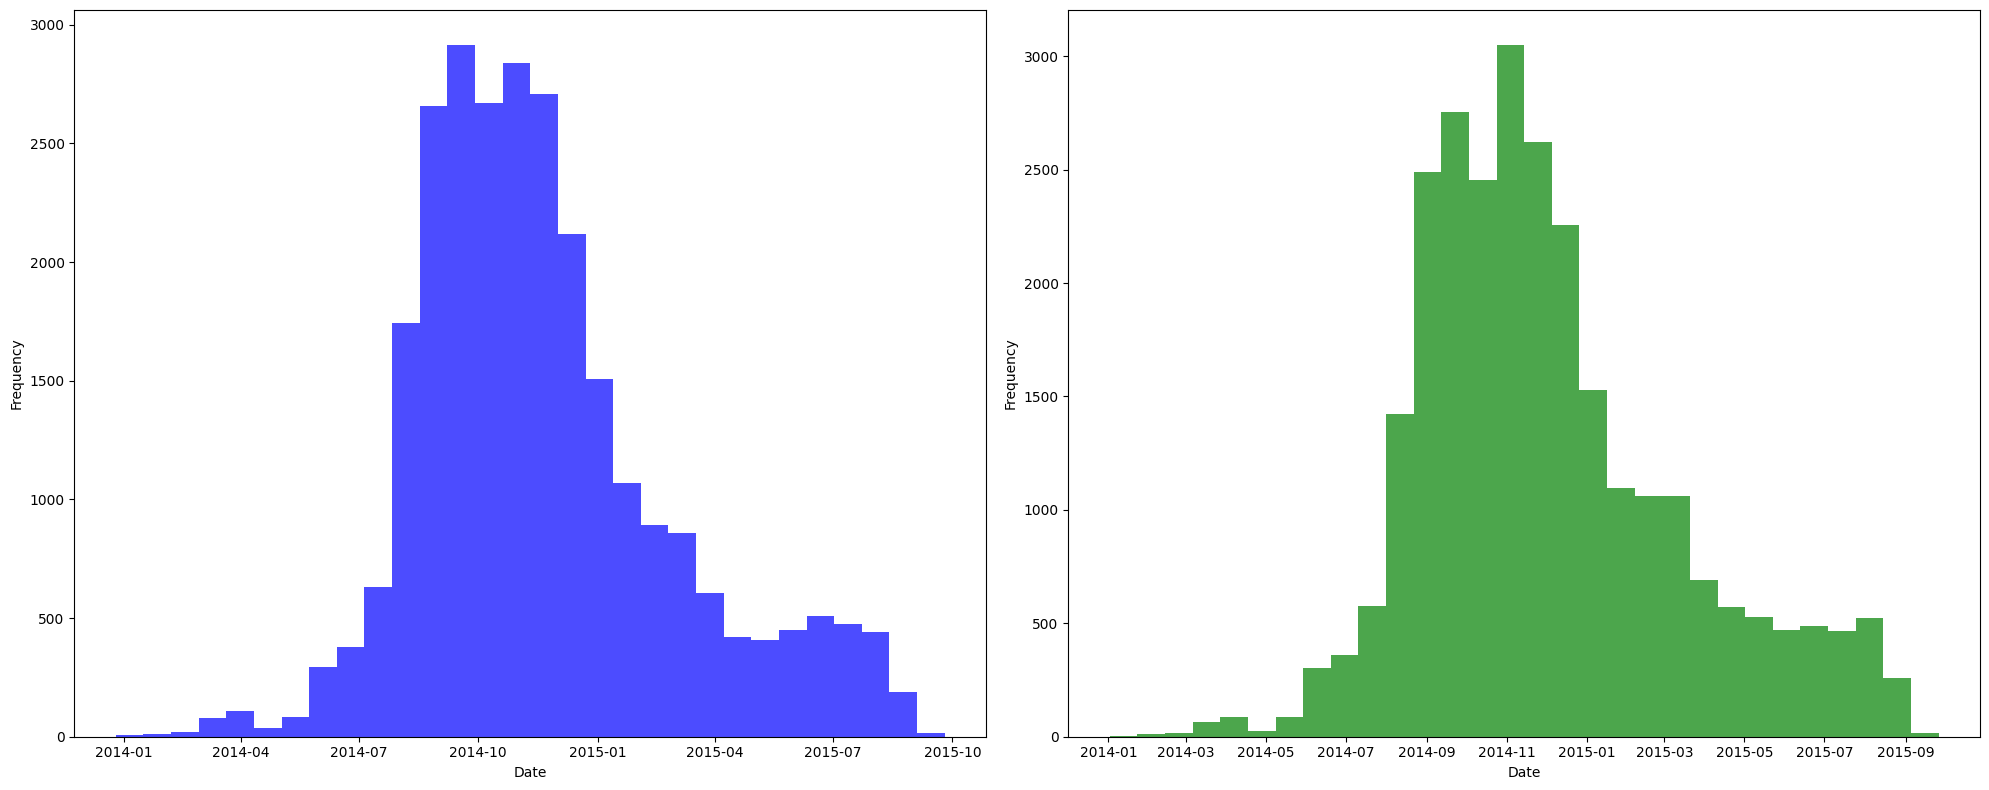

In [40]:
plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.hist(ebola['DateOnset'].dropna(), bins=30, color='blue', alpha=0.7)
# plt.title('DateOnset Distribution')
plt.xlabel('Date')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(ebola['DateReport'].dropna(), bins=30, color='green', alpha=0.7)
# plt.title('DateReport Distribution')
plt.xlabel('Date')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('./images/date_distribution.pdf', bbox_inches='tight')
plt.show()

### 2. Plot Case Definition

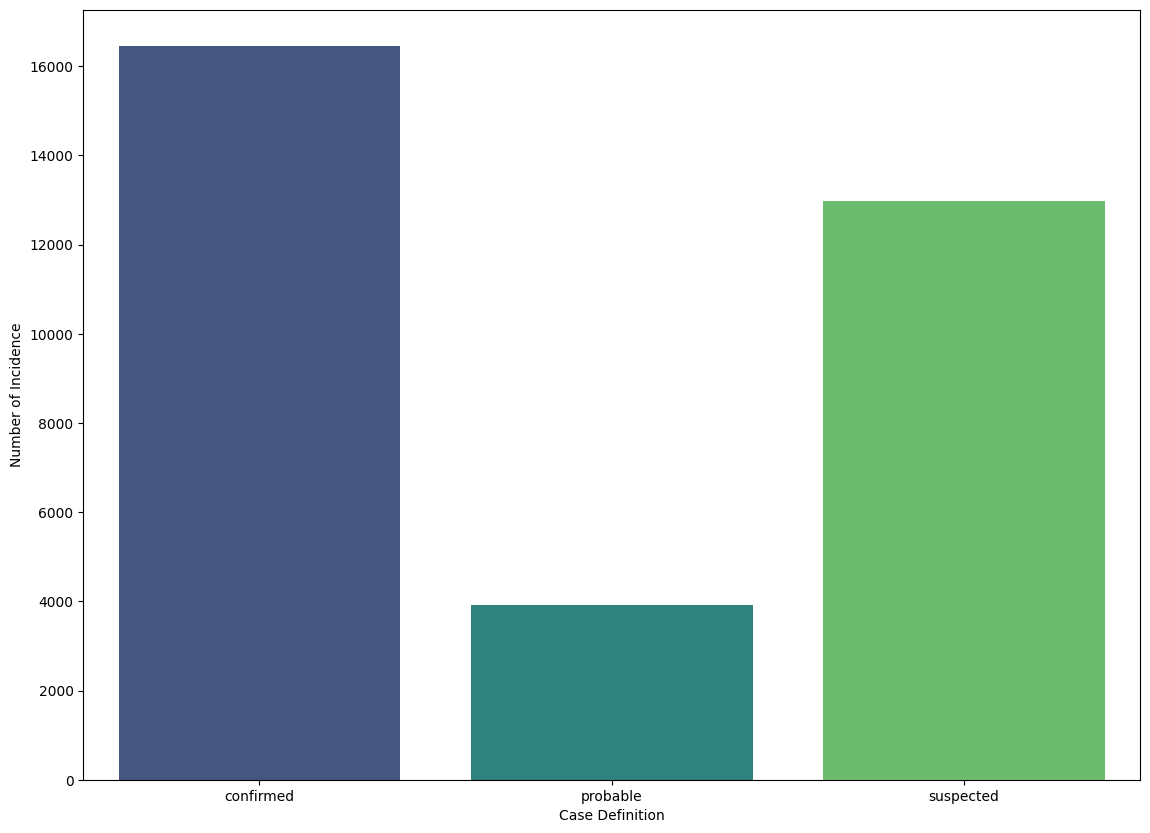

In [41]:
plt.figure(figsize=(30, 10))
plt.subplot(1, 2, 1)
sns.countplot(data = ebola,
              x='EpiCaseDef',
              hue='EpiCaseDef',
              palette='viridis')
# plt.title('Case definition - Confirmed, Probable, Suspected')
plt.xlabel('Case Definition')
plt.ylabel('Number of Incidence')
plt.savefig('./images/Case_definition.pdf', bbox_inches='tight')

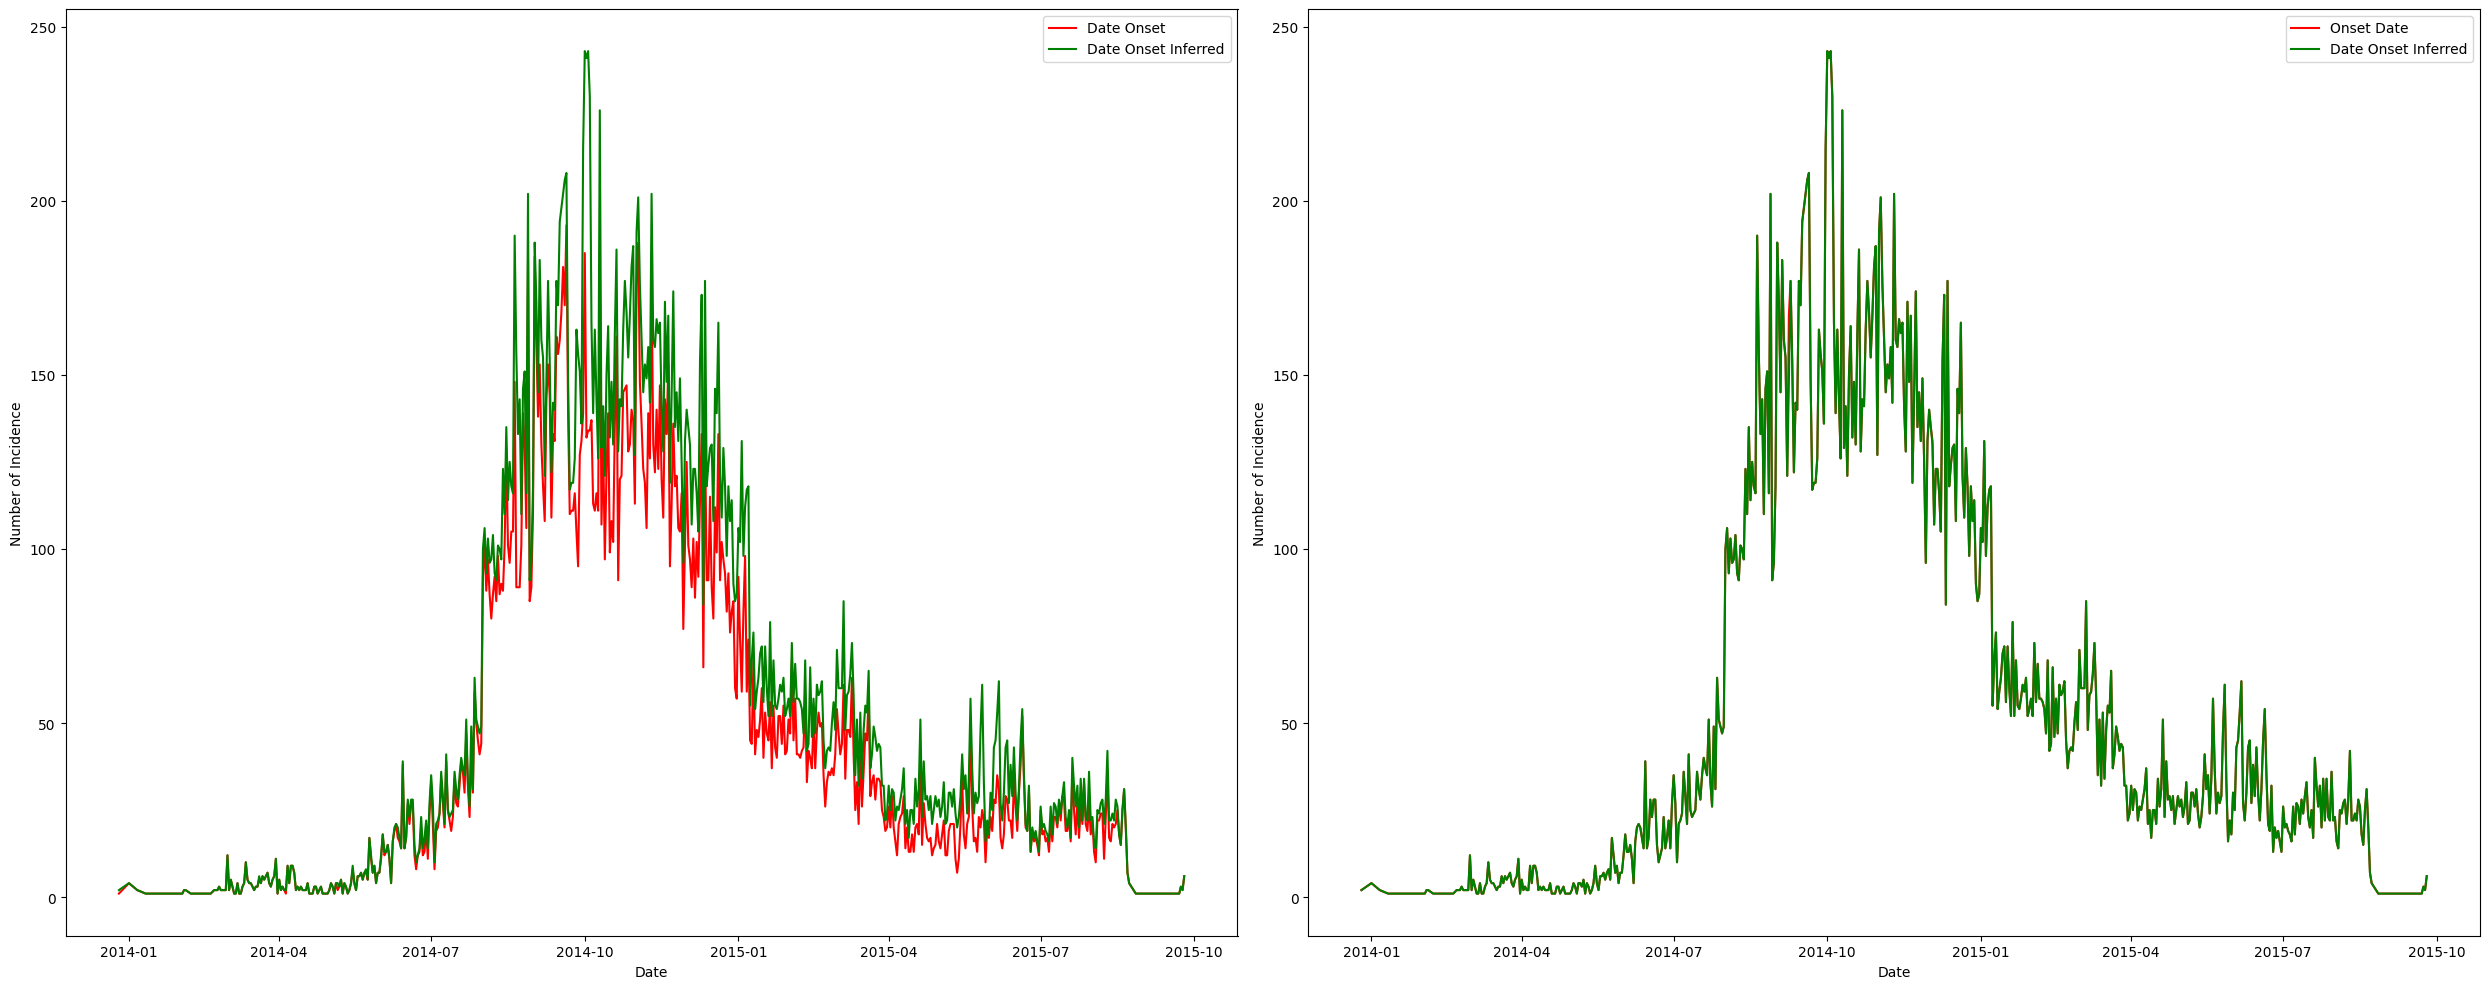

In [42]:
## plot the number of cases over time
plt.figure(figsize=(25, 10))
plt.subplot(1, 2, 1)
plt.plot(ebola['DateOnset'].value_counts().sort_index(), linestyle='-', color='red')
plt.plot(ebola['DateOnsetInferred'].value_counts().sort_index(), linestyle='-', color='green')
# plt.title('Number of Incidence Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Incidence')
plt.legend(['Date Onset', 'Date Onset Inferred'])
# plt.xticks(rotation=45)
# plt.grid()
## save plot
# plt.savefig('./images/cases_over_time.png', bbox_inches='tight')
# plt.show()

plt.subplot(1, 2, 2)
plt.plot(ebola['OnsetDate'].value_counts().sort_index(), linestyle='-', color='red')
plt.plot(ebola['DateOnsetInferred'].value_counts().sort_index(), linestyle='-', color='green')
# plt.title('Number of Incidence Over Time (With Imputed Values)')
plt.xlabel('Date')
plt.ylabel('Number of Incidence')
plt.legend(['Onset Date', 'Date Onset Inferred'])
# plt.xticks(rotation=45)
plt.tight_layout()
# plt.grid()
## save plot
plt.savefig('./images/cases_over_time.pdf', bbox_inches='tight')
plt.show()

### 3. Plot Daily cases

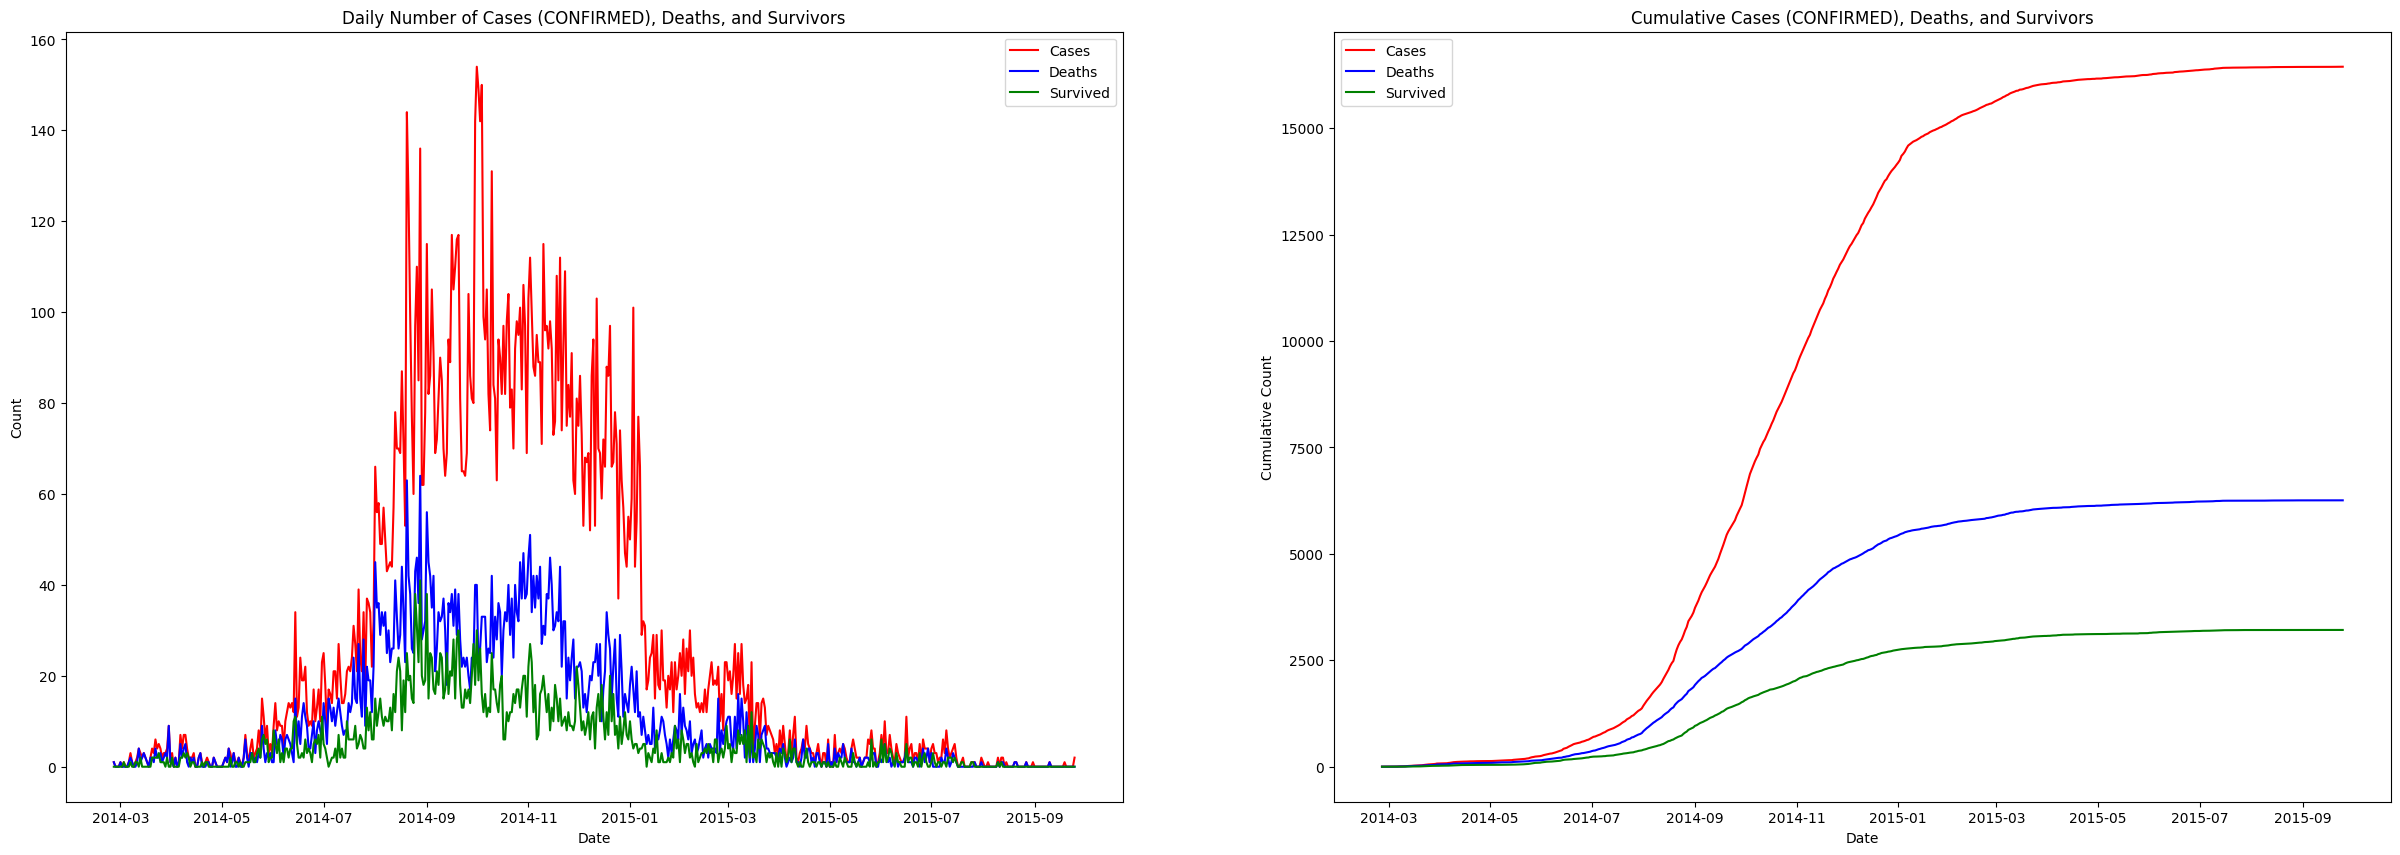

In [43]:
plt.figure(figsize=(30, 10))
plt.subplot(1, 2, 1)
plt.plot(cases_by_day["DateOnset"], cases_by_day["Cases"], linestyle="-", color="red", label="Cases")
plt.plot(death_by_day["DateOnset"], death_by_day["FinalStatus"], linestyle="-", color="blue", label="Deaths")
plt.plot(survive_by_day["DateOnset"], survive_by_day["FinalStatus"], linestyle="-", color="green", label="Survived")
plt.title("Daily Number of Cases (CONFIRMED), Deaths, and Survivors")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
# plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(cases_by_day["DateOnset"], cases_by_day["CumulativeCases"], linestyle="-", color="red", label="Cases")
plt.plot(death_by_day["DateOnset"], death_by_day["CummulativeDeaths"], linestyle="-", color="blue", label="Deaths")
plt.plot(survive_by_day["DateOnset"], survive_by_day["CummulativeSurvival"], linestyle="-", color="green", label="Survived")
plt.title("Cumulative Cases (CONFIRMED), Deaths, and Survivors")
plt.xlabel("Date")
plt.ylabel("Cumulative Count")
plt.legend()
# plt.tight_layout()
# plt.grid(True)
plt.savefig('./images/daily_deaths.pdf', bbox_inches='tight')
plt.show()

### 4. Plot Incidence by country

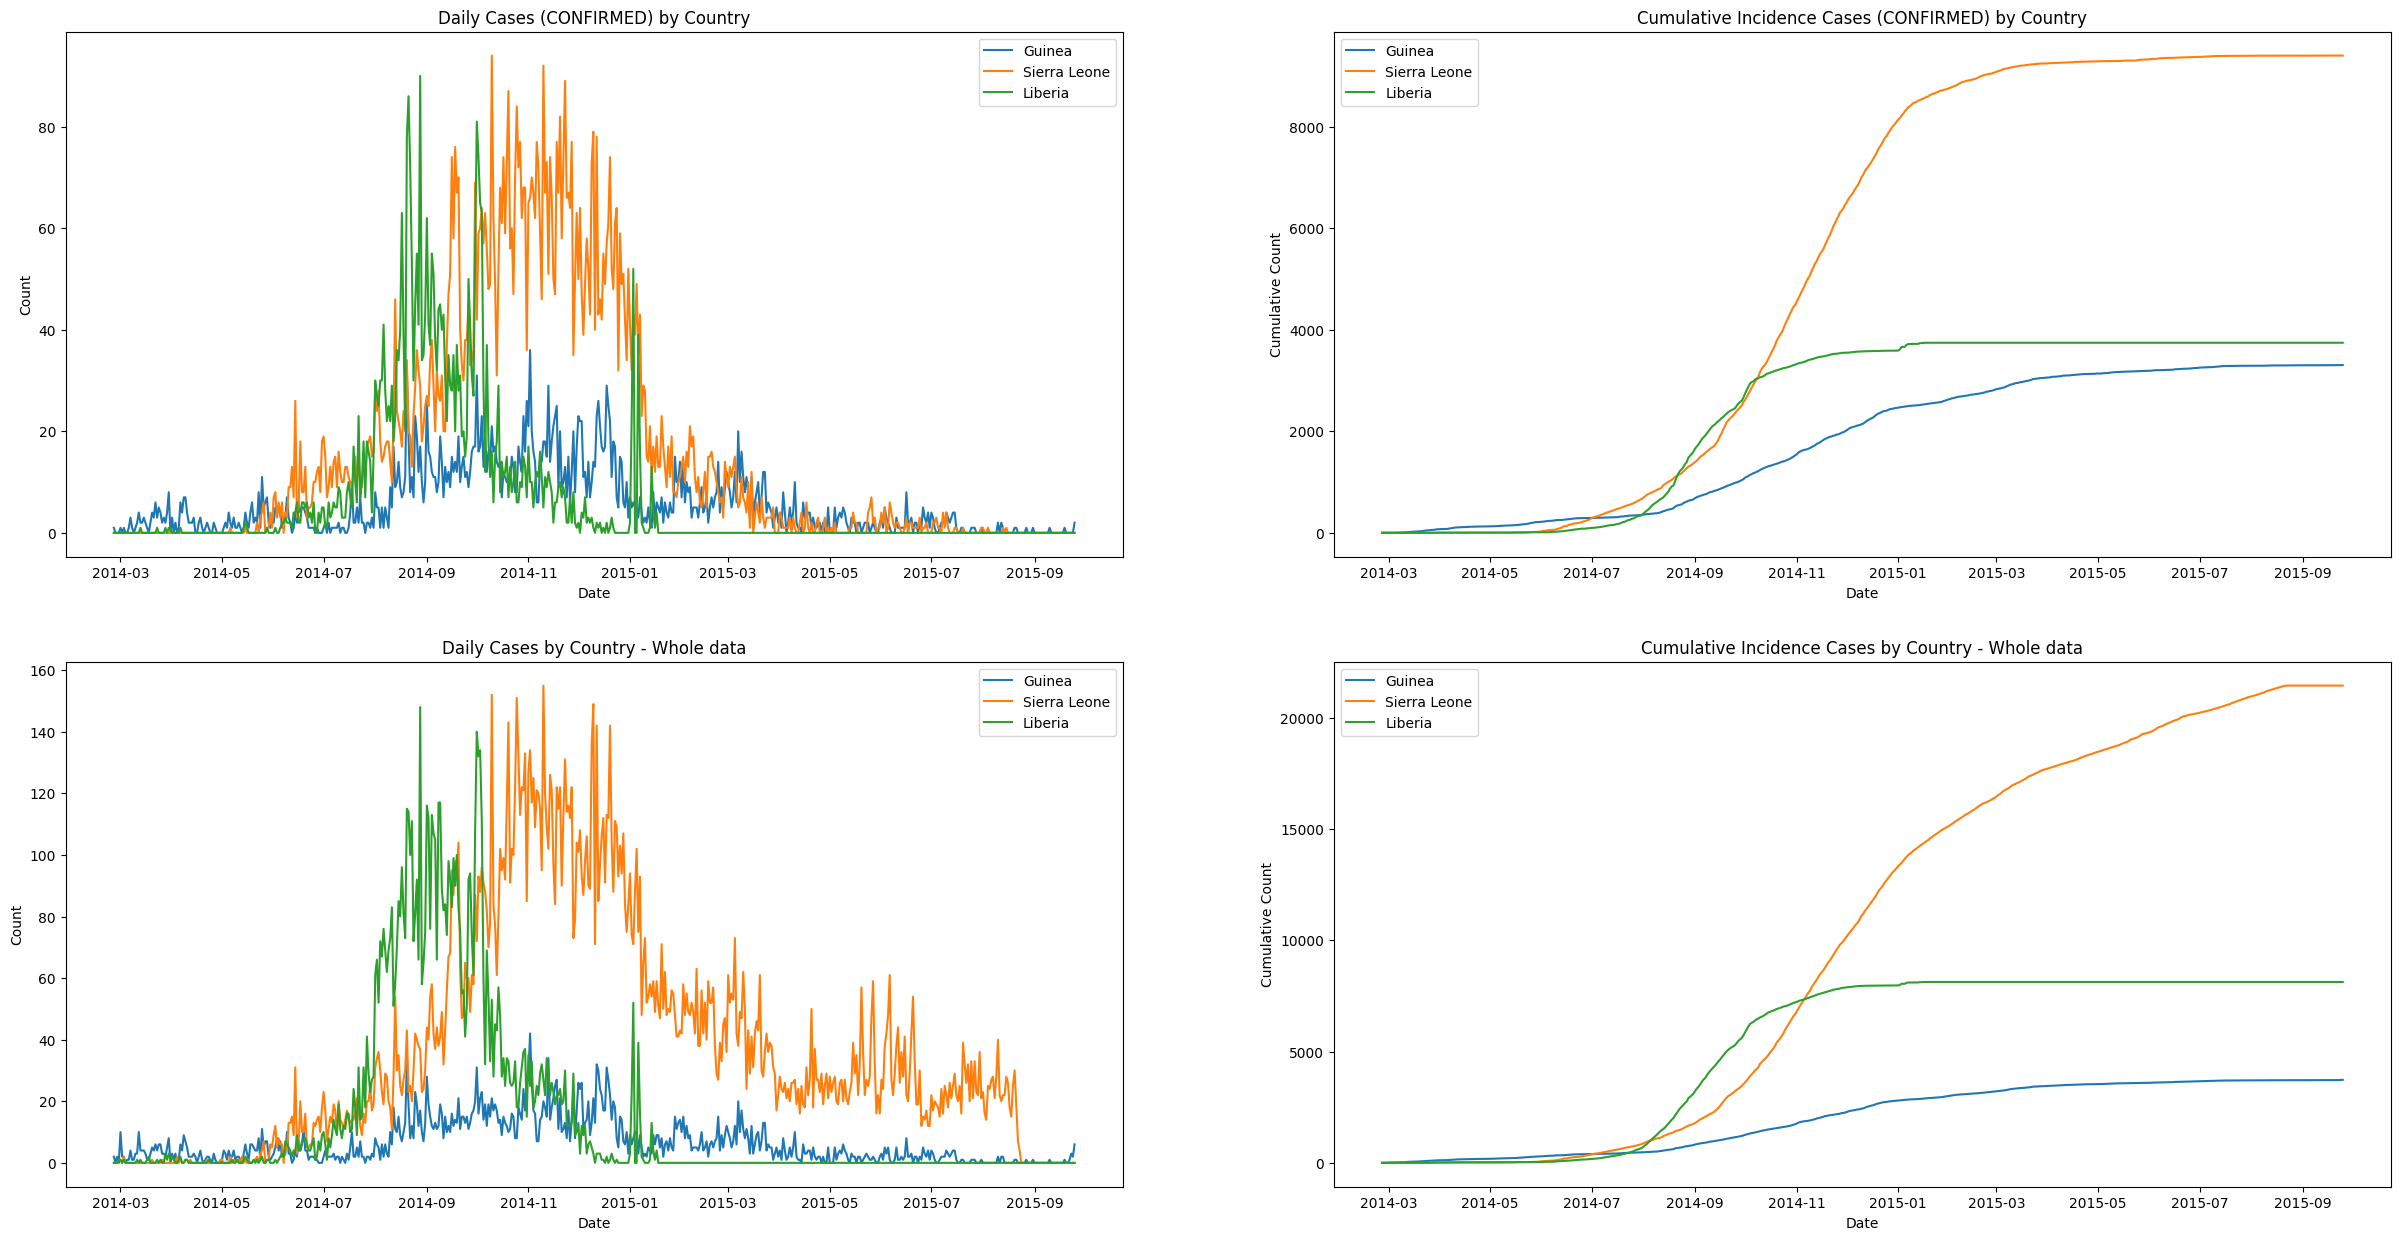

In [44]:
plt.figure(figsize=(30, 15))
plt.subplot(2, 2, 1)
for country in ebola_confirmed["Country"].unique():
    country_data = ebola_confirmed[ebola_confirmed["Country"] == country].groupby("OnsetDate").size().reset_index(name="Cases")
    country_data = country_data.set_index("OnsetDate").reindex(all_dates, fill_value=0).reset_index().rename(columns={"index": "DateOnset"})
    plt.plot(country_data["DateOnset"], country_data["Cases"], linestyle="-", label=country)
plt.title("Daily Cases (CONFIRMED) by Country")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
# plt.grid(True)

plt.subplot(2, 2, 2)
for country in ebola_confirmed["Country"].unique():
    country_data = ebola_confirmed[ebola_confirmed["Country"] == country].groupby("OnsetDate").size().reset_index(name="Cases")
    country_data = country_data.set_index("OnsetDate").reindex(all_dates, fill_value=0).reset_index().rename(columns={"index": "DateOnset"})
    country_data["CumulativeCases"] = country_data["Cases"].cumsum()
    plt.plot(country_data["DateOnset"], country_data["CumulativeCases"], linestyle="-", label=country)
plt.title("Cumulative Incidence Cases (CONFIRMED) by Country")
plt.xlabel("Date")
plt.ylabel("Cumulative Count")
plt.legend()
# plt.tight_layout()
# plt.grid()
# plt.savefig('./images/cases_by_country.png', bbox_inches='tight')


plt.subplot(2, 2, 3)
for country in ebola["Country"].unique():
    country_data = ebola[ebola["Country"] == country].groupby("OnsetDate").size().reset_index(name="Cases")
    country_data = country_data.set_index("OnsetDate").reindex(all_dates, fill_value=0).reset_index().rename(columns={"index": "DateOnset"})
    plt.plot(country_data["DateOnset"], country_data["Cases"], linestyle="-", label=country)
plt.title("Daily Cases by Country - Whole data")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
# plt.grid(True)

plt.subplot(2, 2, 4)
for country in ebola["Country"].unique():
    country_data = ebola[ebola["Country"] == country].groupby("OnsetDate").size().reset_index(name="Cases")
    country_data = country_data.set_index("OnsetDate").reindex(all_dates, fill_value=0).reset_index().rename(columns={"index": "DateOnset"})
    country_data["CumulativeCases"] = country_data["Cases"].cumsum()
    plt.plot(country_data["DateOnset"], country_data["CumulativeCases"], linestyle="-", label=country)
plt.title("Cumulative Incidence Cases by Country - Whole data")
plt.xlabel("Date")
plt.ylabel("Cumulative Count")
plt.legend()
# plt.tight_layout()
# plt.grid()
plt.savefig('./images/cases_by_country.pdf', bbox_inches='tight')
plt.show()

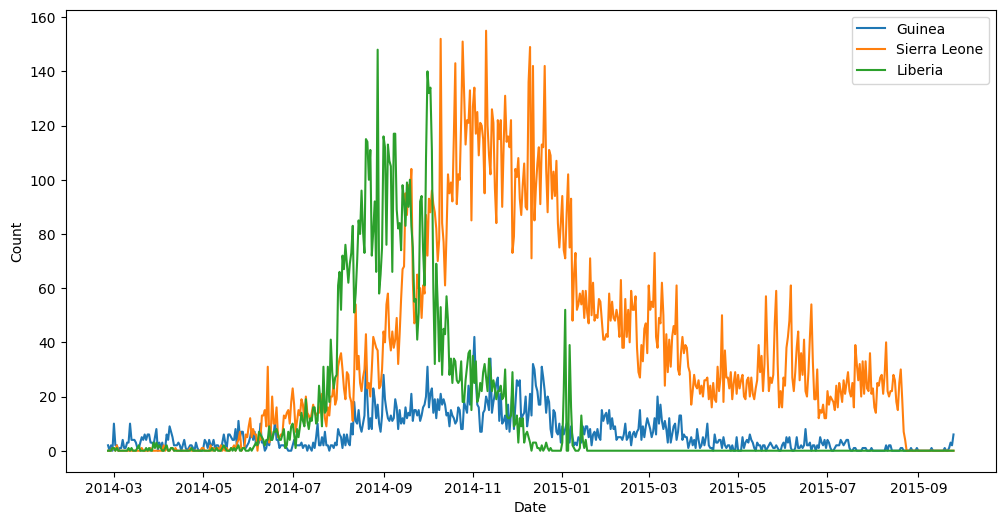

In [45]:
plt.figure(figsize=(12, 6))
for country in ebola["Country"].unique():
    country_data = ebola[ebola["Country"] == country].groupby("OnsetDate").size().reset_index(name="Cases")
    country_data = country_data.set_index("OnsetDate").reindex(all_dates, fill_value=0).reset_index().rename(columns={"index": "DateOnset"})
    plt.plot(country_data["DateOnset"], country_data["Cases"], linestyle="-", label=country)
# plt.title("Daily Cases by Country - Whole data")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.savefig('./images/cases_by_country.pdf', bbox_inches='tight')
plt.show()

In [46]:
ebola['OnsetDate'].sort_values(ascending=False)

3053    2015-09-25
2604    2015-09-25
2694    2015-09-25
3422    2015-09-25
2948    2015-09-25
           ...    
14364   2014-01-01
2890    2014-01-01
1496    2014-01-01
16233   2013-12-26
7125    2013-12-26
Name: OnsetDate, Length: 33338, dtype: datetime64[ns]

### 5. Let's plot the Spatia Cases accross the countries

In [47]:
# Count cases by country
cases_by_country = ebola["CL_DistrictRes"].value_counts().reset_index()
cases_by_country.columns = ['Districts', 'cases']

# Merge with world data
world_with_cases = districts_filter.merge(cases_by_country, how='left', left_on='NAME_2', right_on='Districts')

In [48]:
print(world_with_cases[world_with_cases['Districts'].isna()])


   COUNTRY  NAME_1    NAME_2  \
69  Guinea    Boké    Gaoual   
70  Guinea    Boké  Koundara   
79  Guinea  Kankan  Mandiana   
86  Guinea    Labé    Koubia   
87  Guinea    Labé      Labé   
88  Guinea    Labé   Lélouma   
92  Guinea   Mamou     Mamou   

                                             geometry Districts  cases  
69  POLYGON ((-13.2189 12.00537, -13.20773 12.0101...       NaN    NaN  
70  MULTIPOLYGON (((-13.28435 12.0102, -13.28436 1...       NaN    NaN  
79  POLYGON ((-8.00599 10.12227, -8.01127 10.10785...       NaN    NaN  
86  POLYGON ((-11.86177 11.52946, -11.87452 11.503...       NaN    NaN  
87  POLYGON ((-12.20174 11.49307, -12.16503 11.493...       NaN    NaN  
88  POLYGON ((-12.98692 11.24508, -12.99171 11.256...       NaN    NaN  
92  POLYGON ((-12.16398 10.00151, -12.14164 10.007...       NaN    NaN  


----------------------------------------------------------------------------------------------------------------------------

These Districts do not have any incidence recorded in the Ebola dataset. Hence we will use **GREEN** color as their map representation. There are **7** Districsts that do not have any incidence recorded in the data.

----------------------------------------------------------------------------------------------------------------------------

In [49]:
# world_with_cases['cases']=world_with_cases['cases'].fillna(0)
districts_filter['COUNTRY'].unique()

array(['Liberia', 'Guinea', 'Sierra Leone'], dtype=object)

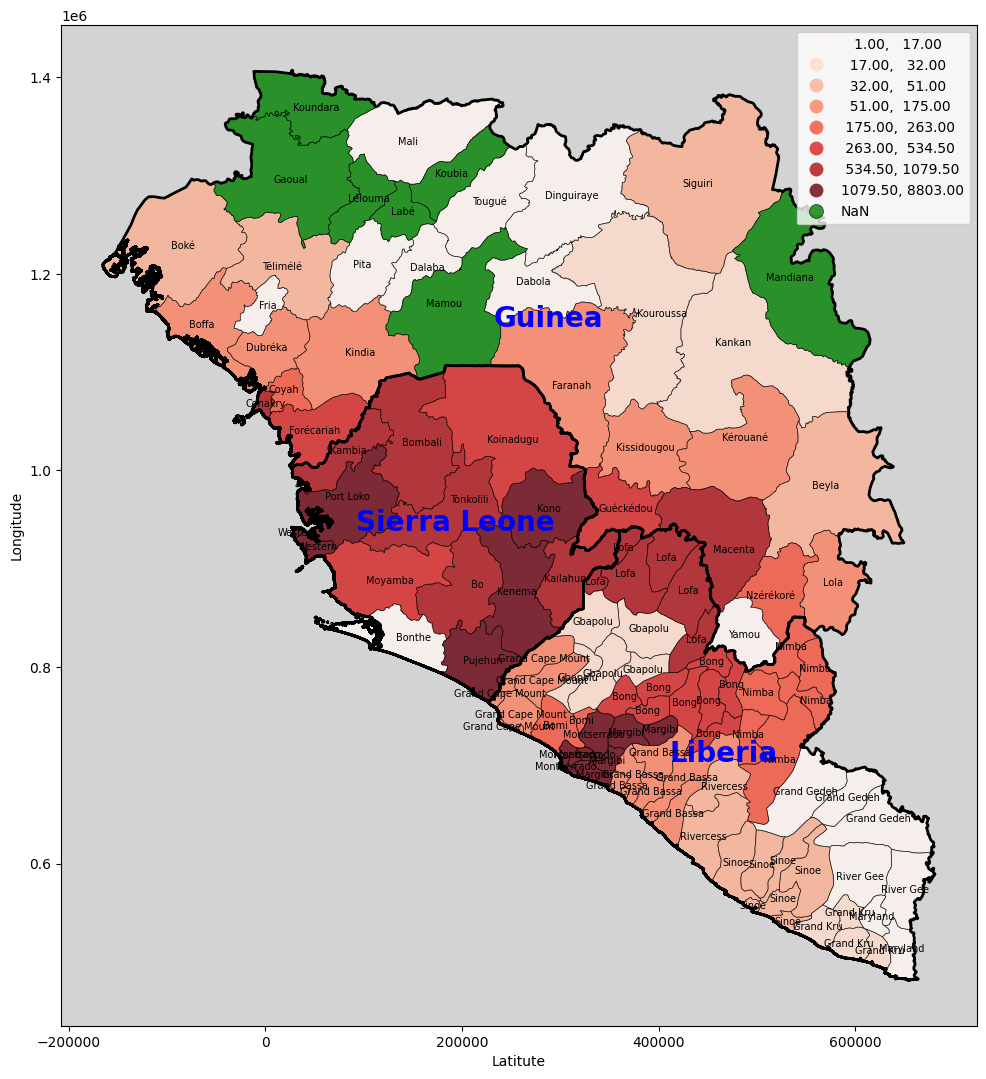

In [50]:
# Reproject to UTM Zone 29N (suitable for Liberia, Sierra Leone, Guinea)
world_with_cases = world_with_cases.to_crs(epsg=32629)

# Load country boundaries and filter for Liberia, Sierra Leone, and Guinea
countries = country_filter[country_filter['COUNTRY'].isin(['Liberia', 'Sierra Leone', 'Guinea'])]
countries = countries.to_crs(epsg=32629)  # Reproject to match world_with_cases

# Plot
fig, ax = plt.subplots(figsize=(30, 13))
ax.set_facecolor('lightgray')  # Add a light background

# Plot the choropleth map for the country

world_with_cases.plot(
            column='cases', ax=ax, legend=True,
            missing_kwds={'color': 'green'},
            cmap='Reds', edgecolor='black',
            linewidth=0.5, alpha=0.8,
            scheme='quantiles', k=8
        )

# Plot country boundaries with a thicker line
countries.boundary.plot(ax=ax, color='black', linewidth=2)

# Add country names at the centroids
for idx, row in countries.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, row['COUNTRY'], fontsize=20, fontweight='bold', color='blue', ha='center', va='center')

# Add region names using representative_point() to reduce overlap
for point, label in zip(world_with_cases.geometry.representative_point(),
                        world_with_cases['NAME_2']):
    ax.text(point.x, point.y, label, fontsize=7, ha='center', va='center')

# Update the title and remove axes labels
# plt.title('Ebola Cases by Districts in Liberia, Sierra Leone, and Guinea')
ax.set_xlabel('Latitute')
ax.set_ylabel('Longitude')

# Save the plot
plt.savefig('./images/cases_by_district_map2.pdf', bbox_inches='tight')

plt.show()

### Country by Country Ebola Cases

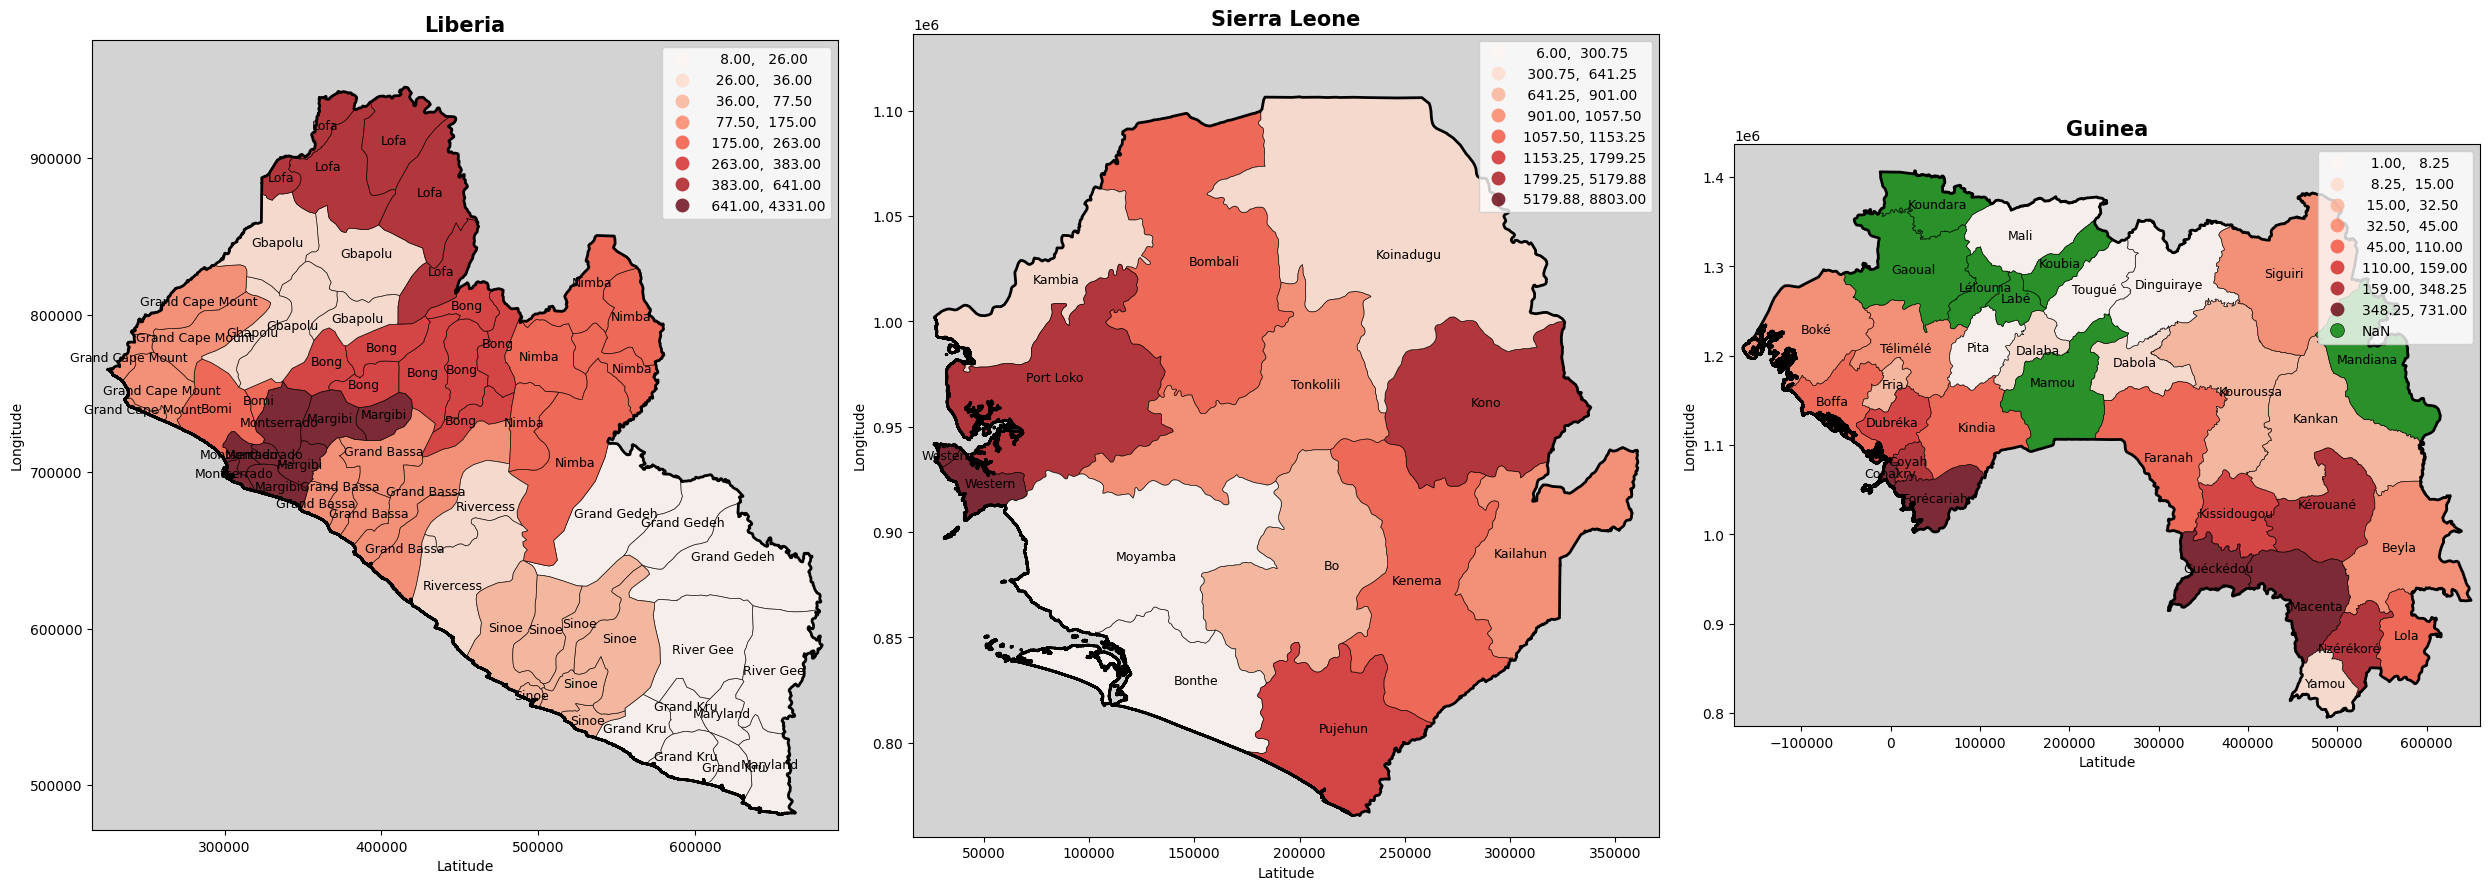

In [51]:
# Reproject to UTM Zone 29N (suitable for Liberia, Sierra Leone, Guinea)
world_with_cases = world_with_cases.to_crs(epsg=32629)

# Load country boundaries and filter for Liberia, Sierra Leone, and Guinea
countries = country_filter[country_filter['COUNTRY'].isin(['Liberia', 'Sierra Leone', 'Guinea'])]
countries = countries.to_crs(epsg=32629)  # Reproject to match world_with_cases

# Create a figure with 3 subplots (one for each country)
fig, axes = plt.subplots(1, 3, figsize=(25, 15))
# fig.suptitle('Ebola Cases by Districts in Liberia, Sierra Leone, and Guinea', fontsize=16)

# List of countries to iterate over
country_list = ['Liberia', 'Sierra Leone', 'Guinea']

# Plot each country in a separate subplot
for ax, country in zip(axes, country_list):
    ax.set_facecolor('lightgray')  # Add a light background

    # Filter the data for the specific country
    country_data = world_with_cases[world_with_cases['COUNTRY'] == country]
    country_boundary = countries[countries['COUNTRY'] == country]

    # Plot the choropleth map for the country

    country_data.plot(
            column='cases', ax=ax, legend=True,
            missing_kwds={'color': 'green'},
            cmap='Reds', edgecolor='black',
            linewidth=0.5, alpha=0.8,
            scheme='quantiles', k=8
    )

    # Plot country boundary with a thicker line
    country_boundary.boundary.plot(ax=ax, color='black', linewidth=2)

    # Add region names using representative_point() to reduce overlap
    for point, label in zip(country_data.geometry.representative_point(), country_data['NAME_2']):
        ax.text(point.x, point.y, label, fontsize=9, ha='center', va='center')

    # Set title for each subplot
    ax.set_title(country, fontsize=15, fontweight='bold')
    ax.set_xlabel('Latitude')
    ax.set_ylabel('Longitude')

    # Set consistent aspect ratio for all subplots
    ax.set_aspect('equal')

    # Optional: Adjust axis limits to focus on the country (this helps with consistent scaling)
    bounds = country_data.total_bounds
    ax.set_xlim(bounds[0] - 10000, bounds[2] + 10000)
    ax.set_ylim(bounds[1] - 10000, bounds[3] + 30000)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the plot
plt.savefig('./images/cases_by_district_separate.pdf', bbox_inches='tight')

plt.show()

# 4. Prepare the Data for Modelling

In [52]:
## get patches
patch_names = ["Guinea", "Liberia", "Sierra Leone"]
n_patches = len(patch_names)

## get the start date and end date
start_date = ebola["OnsetDate"].min()
end_date = ebola["OnsetDate"].max()

# Create a date range for weekly data
weeks = pd.date_range(start=start_date, end=end_date, freq="W-MON")
T = len(weeks)

# Create an empty array to store observed cases
I_obs = np.zeros((T, n_patches))

# Fill the observed cases array with weekly data for each patch
for i, country in enumerate(patch_names):
    country_data = ebola[ebola["Country"] == country]
    weekly_cases = country_data.groupby(pd.Grouper(key="OnsetDate", freq="W-MON")).size()
    weekly_cases = weekly_cases.reindex(weeks, fill_value=0)
    I_obs[:, i] = weekly_cases.values

# Create a DataFrame for plotting
time = np.arange(1, T + 1)
data_plot = pd.DataFrame(I_obs, columns=patch_names)
data_plot["Time"] = time
data_plot["Week"] = weeks[:].strftime("%Y-%m-%d")
# Melt the DataFrame for easier plotting
data_plot = data_plot.melt(id_vars=["Time", "Week"], var_name="Patches", value_name="Cases")

In [53]:
data_plot

,Time,Week,Patches,Cases
0,1,2013-12-30,Guinea,0.0
1,2,2014-01-06,Guinea,4.0
2,3,2014-01-13,Guinea,1.0
3,4,2014-01-20,Guinea,2.0
4,5,2014-01-27,Guinea,1.0
...,...,...,...,...
268,87,2015-08-24,Sierra Leone,100.0
269,88,2015-08-31,Sierra Leone,0.0
270,89,2015-09-07,Sierra Leone,0.0
271,90,2015-09-14,Sierra Leone,0.0


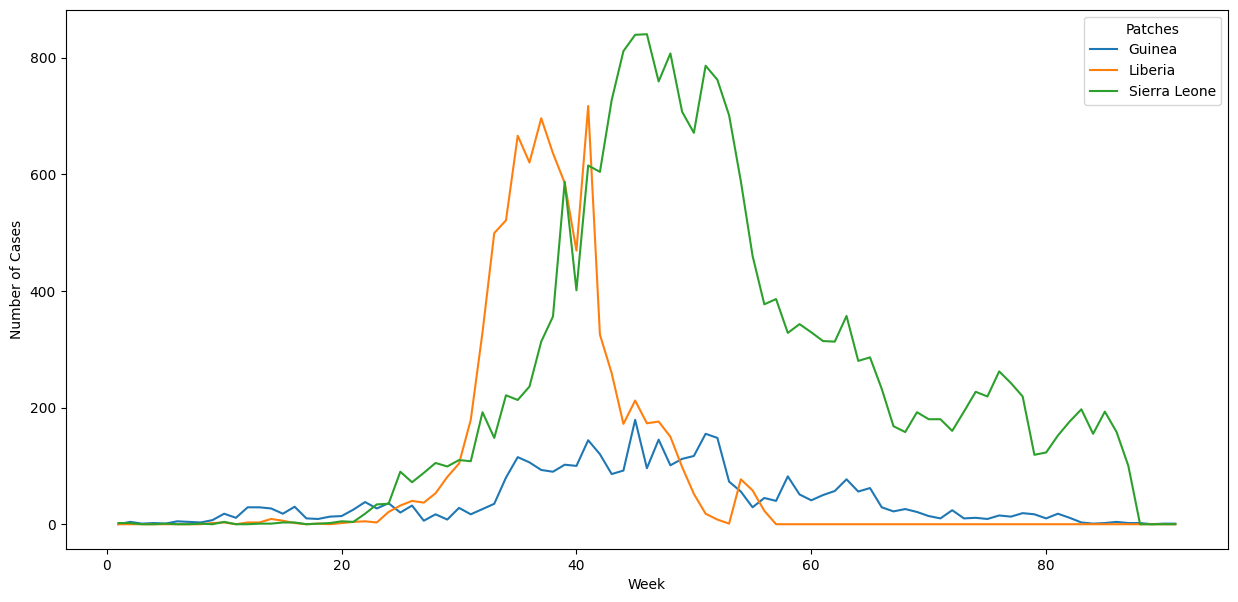

In [54]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=data_plot, x="Time", y="Cases", hue="Patches")
# plt.title("Weekly New Ebola Cases")
plt.xlabel("Week")
plt.ylabel("Number of Cases")
# plt.grid(True)
plt.savefig('./images/weekly_cases.pdf', bbox_inches='tight')
plt.show()

# 4. Fitting a Simple SEIR model


## 1. Simple SEIR Model

With this simple model, Guinea, Liberia, and Sierra Leone will be treated as one patch, and we’ll fit a Susceptible(S), Exposed(E), Infectious(I), and Recovered(R) model to the entire incidence data. The model is given below:

$$ \frac{dS}{dt} = -\beta S \frac{I}{N}$$

$$ \frac{dE}{dt} = \beta S \frac{I}{N} - \sigma E$$

$$\frac{dI}{dt} = \sigma E - \gamma I$$

$$\frac{dR}{dt} = \gamma I$$

Where:
- $ S, E, I, R $: Susceptible, Exposed, Infectious, and Recovered individuals respectively.
- $ N $: Total population.
- $ \beta$: Transmission rate.
- $ \sigma $: Rate of progression from Exposed to Infectious (inverse of the latent period).
- $ \gamma $: Recovery rate (inverse of the infectious period).

### New Infections
- The rate at which individuals move from the Exposed ($E$) to the infectious ($I$) compartment at time t is given as:
$$
\sigma E(t)
$$

- The number of new infectious individuals at time $ t $ is given by the inflow into the Infectious compartment:
  $$
  \text{New Infectious}(t) = \int_{t-1}^t\sigma E(s) ds
  $$

### Observation Model
- We'll use a Negative Binomial distribution to model the observed incidence data, accounting for overdispersion:
  $$
  I_{\text{obs}}[t] \sim \text{NegativeBinomial}(\sigma E(t), \phi)
  $$
  where $ \phi $ is the dispersion parameter.

### Initial Conditions and Parameters
- **Initial Conditions**:
  - At $ t = 0 $, assume $ S(0) \approx N$, $ E(0) = I(0) = 1 $, $ R(0) = 0 $, since the outbreak started with a small number of exposed and infectious individuals.

- **Parameters to Estimate**:
  - $ \sigma $: Rate of progression from Exposed to Infectious (fixed at 1/5.3 days, based on Faye et al., 2015).
  - $ \gamma $: Recovery rate (fixed at 1/5 days, based on Faye et al., 2015).


- **Parameters to be Fitted**
  - $ \beta $: Transmission rate for each patch.
  - $ \phi $: Dispersion parameter for the Negative Binomial distribution.


### Discretization
Since the data is weekly, we'll discretize the ODEs using a daily Euler method and aggregate the new infectious individuals into weekly counts to match `I_obs`.

In [55]:
weekly_cases = data_plot.groupby("Time")["Cases"].sum()

# Ensure y has exactly T elements
y = weekly_cases.values.astype(int)

In [56]:
# # Population sizes (approximate, in millions)
# n = np.array([11.5e6, 4.5e6, 6.8e6])  # Guinea, Liberia, Sierra Leone

# N = 35000  # Total population

# # Prepare data for Stan
# stan_data = {
#     "T": T,
#     "t0": 0,
#     # "n_patches": n_patches,
#     "ts": time,
#     "cases": y,
#     "N": N,
#     "I0": 1
# }

# # Print data summary
# print("Stan Data Summary:")
# print(f"T: {stan_data['T']}")
# # print(f"n_patches: {stan_data['n_patches']}")
# print(f"N: {stan_data['N']}")
# # print(f"E0: {stan_data['E0']}")
# print(f"I0: {stan_data['I0']}")

In [57]:
# # Compile and fit the model
# model = CmdStanModel(stan_file="seir_model.stan")
# fit = model.sample(
#     data=stan_data,
#     chains=4,
#     iter_warmup= 500,
#     iter_sampling=1000
# )

# # Convert to ArviZ InferenceData for analysis
# inference_data = az.from_cmdstanpy(fit)

In [58]:
# print(fit.diagnose())

In [59]:
# # Summary of parameter estimates
# summary = az.summary(inference_data, var_names=["beta", "sigma", "gamma", "R0",'predicted_cases'])
# # print(summary)

# # Extract posterior samples
# posterior = fit.draws_pd()

# ## save the posterior samples
# posterior.to_csv('./Data/posterior_samples.csv', index=False)

In [60]:
# summary

### Trace Plota

In [61]:
# ## trace plots
# az.plot_trace(fit, var_names=["beta", "sigma", "gamma", "R0"])
# plt.show()

In [62]:
# sm = fit.summary()
# print(sm)

In [63]:
# post_pred = pd.DataFrame(sm.filter(like="predicted_cases", axis=0))
# post_pred["t"] = range(1, 92)
# post_pred["incidence"] = list(y)

# post_pred = post_pred.set_index("t")

In [64]:
# post_pred.head()

In [65]:
# plt.figure(figsize=(14, 8))
# for p in range(1):
#     plt.scatter(time, y, label=f"observed",color='red', linestyle="-", marker="o")
#     plt.plot(post_pred.index, post_pred['Mean'], label=f"Predicted", linestyle="--")
#     # plt.fill_between(x = post_pred.index,  y1 = post_pred['5%'], y2 = post_pred['95%'], alpha=0.2)
# plt.title("Observed vs. Predicted Weekly Incidence")
# plt.xlabel("Week")
# plt.ylabel("New Cases")
# plt.legend()
# # plt.grid(True)
# plt.show()

## Posterior Predictive check

In [66]:
# idata_gp = az.from_cmdstanpy(fit)
# custom_summary_fns = {
# 	'median': lambda x: np.percentile(x, 50),
# 	'q2.5': lambda x: np.percentile(x, 2.5),
# 	'q97.5': lambda x: np.percentile(x, 97.5),
# }

# mu_sum_gp = az.summary(idata_gp, var_names=['predicted_cases'], stat_funcs=custom_summary_fns, extend=False)

# # mask = mu_sum_gp.index.str.endswith(', 2]') ## get only the infecetious state
# # mu_sum_gp = mu_sum_gp[mask]


# def plot_posterior_summary(year, y, posterior_summary):
# 	fig, ax = plt.subplots(1, 1, figsize=(14, 8))
# 	ax.scatter(year, y, label='Data',)
# 	ax.plot(year, posterior_summary['median'], label='Posterior Median of Incidence', color='red')
# 	ax.fill_between(year, posterior_summary['q2.5'], posterior_summary['q97.5'], color='gray', alpha=0.2, label='95% CI')
# 	ax.set_title('Posterior Median of Incidence vs Data')
# 	ax.set_xlabel('time (weeks)')
# 	ax.set_ylabel('Cases')
# 	ax.legend()
# 	plt.show()


# # Example usage:
# plot_posterior_summary(time, y, mu_sum_gp)

### Plot SEIR Model

In [67]:
# #import posterior
# posterior = pd.read_csv('./Data/posterior_samples.csv')

In [68]:
# S_fitted = np.zeros(T)
# E_fitted = np.zeros(T)
# I_fitted = np.zeros(T)
# R_fitted = np.zeros(T)

# for t in range(T):
#     S_fitted[t] = posterior[f'y_pred[{t+1},1]'].mean()
#     E_fitted[t] = posterior[f'y_pred[{t+1},2]'].mean()
#     I_fitted[t] = posterior[f'y_pred[{t+1},3]'].mean()
#     R_fitted[t] = posterior[f'y_pred[{t+1},4]'].mean()

# # Normalize fitted results
# S_fitted_frac = S_fitted / N
# E_fitted_frac = E_fitted / N
# I_fitted_frac = I_fitted / N
# R_fitted_frac = R_fitted / N

# # --- Step 4: Plot the SEIR trajectories ---
# plt.figure(figsize=(14, 8))

# # Fitted
# plt.plot(time, S_fitted_frac, label='Susceptible', color='blue')
# plt.plot(time, E_fitted_frac, label='Exposed', color='orange')
# plt.plot(time, I_fitted_frac, label='Infectious', color='red')
# plt.plot(time, R_fitted_frac, label='Recovered', color='green')

# plt.title('SEIR Model')
# plt.xlabel('Time (Weeks)')
# plt.ylabel('Population')
# plt.legend()
# # plt.grid(True)
# plt.show()

# MODEL WITH NO COUPLING EFFECT - INDIVIDUAL MODEL
----------------------------------------------------------------------------------------------------

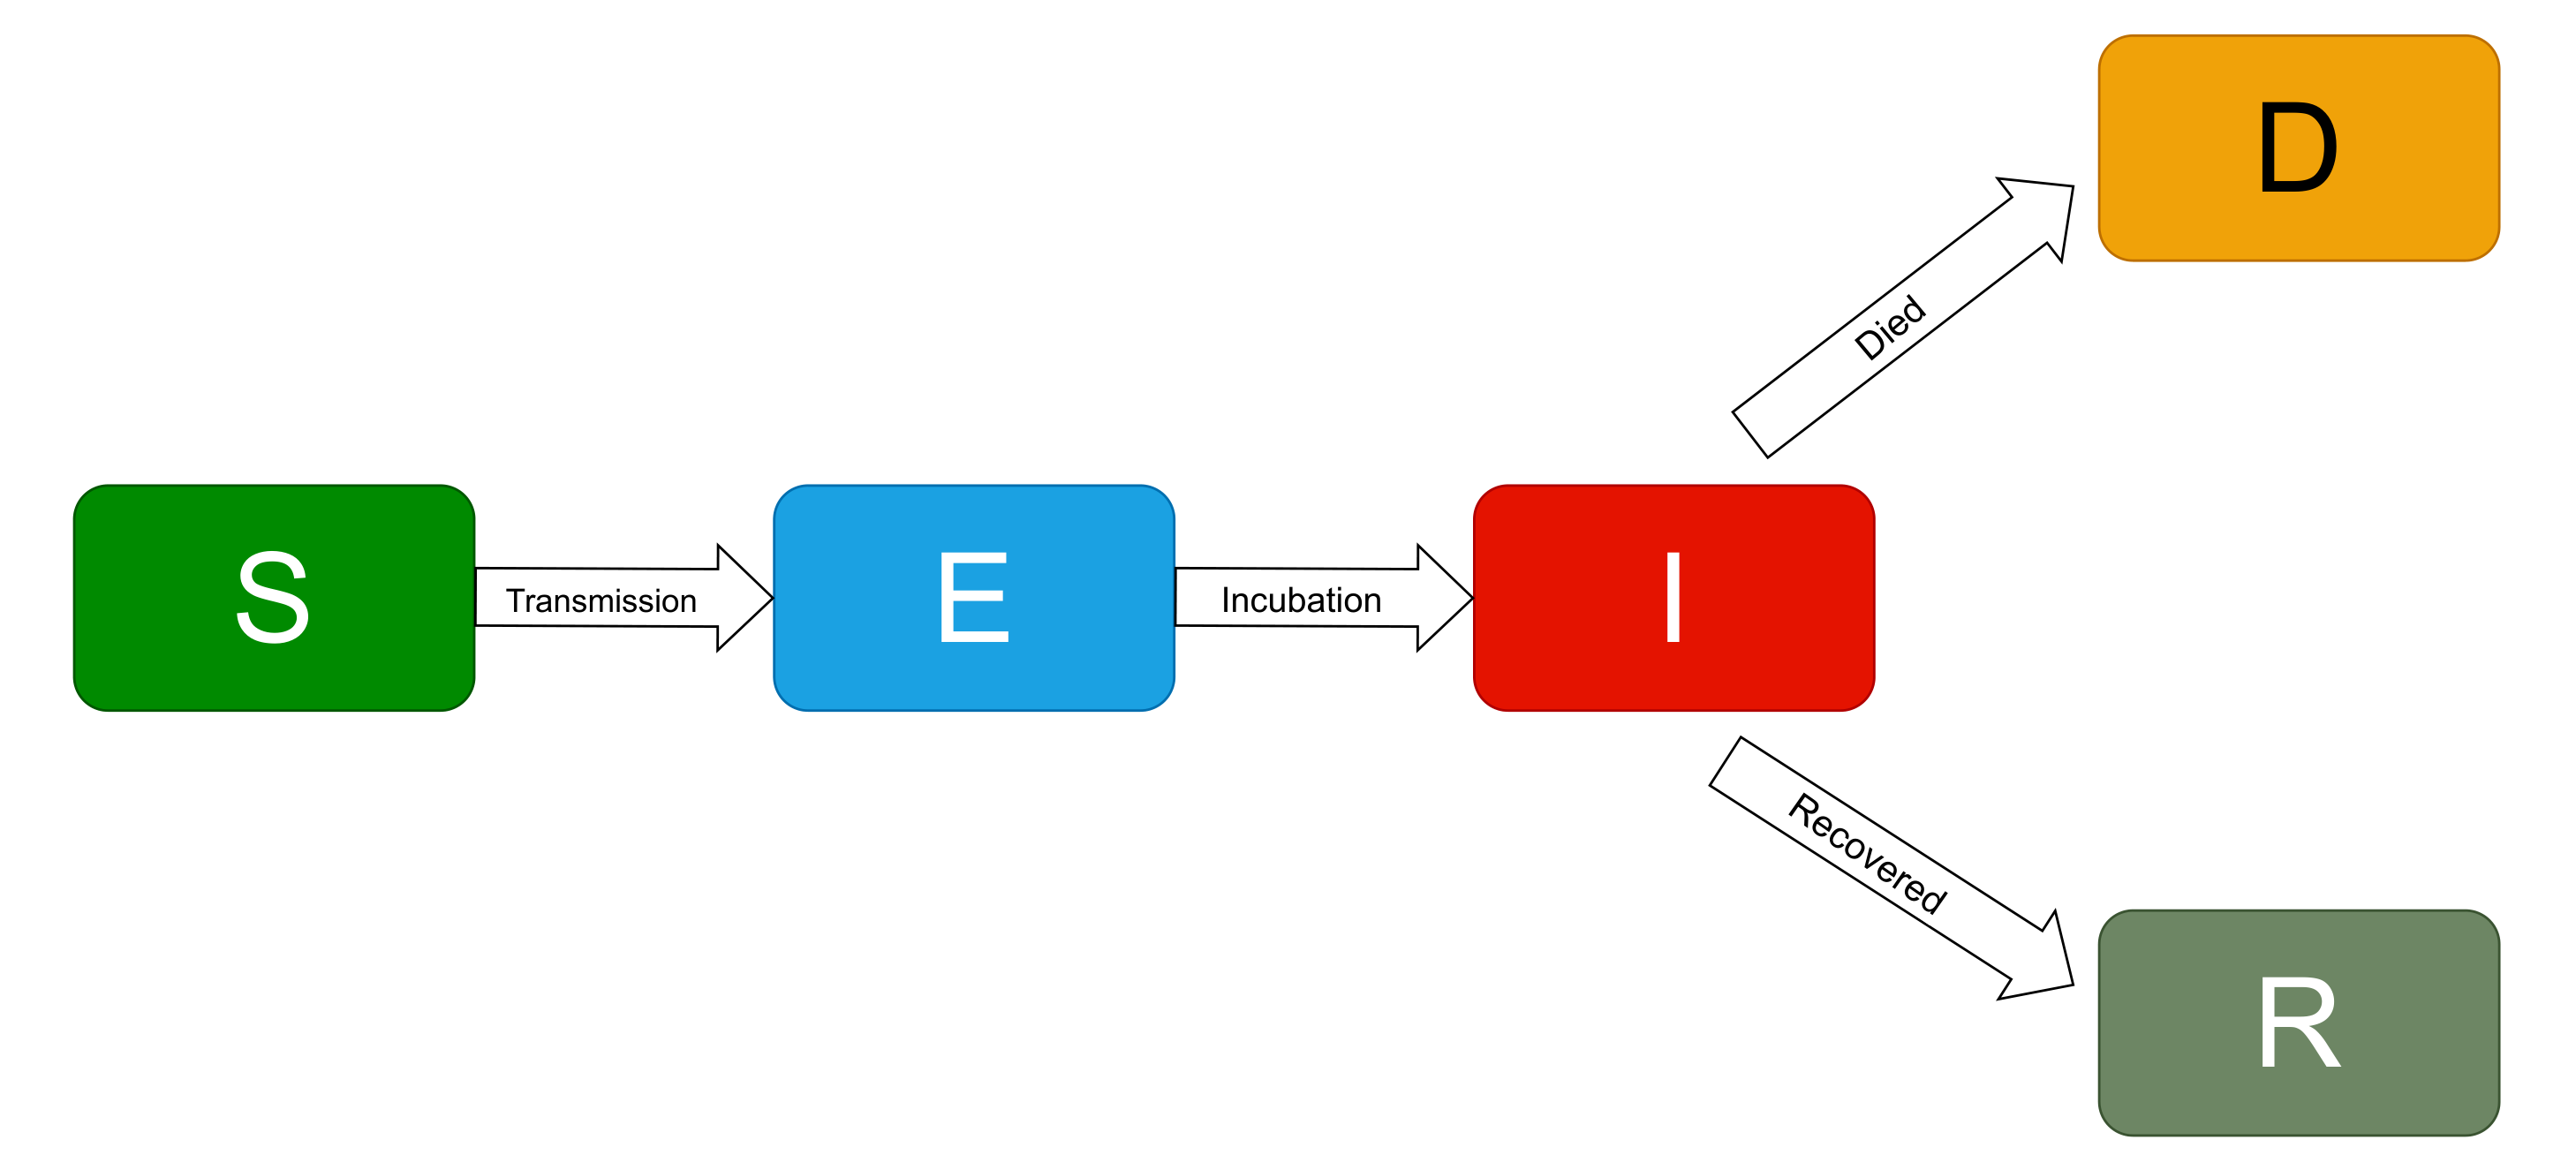

---

With this model, each country Guinea, Liberia, and Sierra Leone will be treated as an independent patch, and we’ll fit a separate Susceptible(S), Exposed(E), Infectious(I), and Recovered(R) model to each country’s incidence data. The dynamics for each patch  $p$ (where $ p $ corresponds to the countries) is given below:

$$ 
\begin{aligned}
\frac{dS_p}{dt} &= -\beta_p S_p \frac{I_p}{N_p}\\

\frac{dE_p}{dt} &= \beta_p S_p \frac{I_p}{N_p} - \sigma_p E_p \\

\frac{dI_p}{dt} &= \sigma_p E_p - \gamma_p I_p \\

\frac{dR_p}{dt} &= \gamma_p I_p
\end{aligned}
$$

Where:
- $ S_p, E_p, I_p, R_p $: Susceptible, Exposed, Infectious, and Recovered individuals in patch $ p $.
- $ N_p $: Total population for patch $ p $.
- $ \beta_p $: Transmission rate in patch $ p $.
- $ \sigma_p $: Rate of progression from Exposed to Infectious (inverse of the latent period).
- $ \gamma_p $: Recovery rate (inverse of the infectious period).

### New Infections
- The rate at which individuals move from the Exposed ($E_p$) to the infectious ($I_p$) compartment at time t is given as:
$$
\sigma E_p(t)
$$

- The number of new infectious individuals at time $ t $ is given by the inflow into the Infectious compartment:
  $$
  \text{New Infectious}(t) = \int_{t-1}^t\sigma E_p(s) ds
  $$
### Observation Model
- We’ll use a Negative Binomial distribution to model the observed incidence data, accounting for overdispersion:
  $$
  I_{\text{obs}}[t, p] \sim \text{NegativeBinomial}(\sigma E_p(t), \phi)
  $$
  where $ \phi $ is the dispersion parameter.

### Initial Conditions and Parameters
- **Initial Conditions**:
  - At $ t = 0 $, assume $ S_p(0) \approx N_p - I_p(0) $, $ E_p(0) = [10, 10, 10], I_p(0) = [10, 1, 1] $, $ R_p(0) = [0, 0,0] $ for each patch, since the outbreak started with a small number of exposed and infectious individuals.
  - $ N_p $: Population sizes for each country (approximate, from **Worldometer** 2014 estimates):
    - Guinea: 11.5 million
    - Liberia: 4.5 million
    - Sierra Leone: 6.8 million

- **Parameters to be fitted**:
  - $ \beta_p $: Transmission rate for each patch.
  - $ \sigma_p $: Rate of progression from Exposed to Infectious.
  - $ \gamma_p $: Recovery rate.


- **Parameters to Estimate**
  - $ \phi $: Dispersion parameter for the Negative Binomial distribution.

### Discretization
Since the data is weekly, we’ll discretize the ODEs using a daily Euler method and aggregate the new infectious individuals into weekly counts to match `I_obs`.

### Prepare the data

In [69]:
g = data_plot[data_plot['Patches']=='Guinea']['Cases'].values.astype(int)
l = data_plot[data_plot['Patches']=='Liberia']['Cases'].values.astype(int)
s = data_plot[data_plot['Patches']=='Sierra Leone']['Cases'].values.astype(int)

# Ensure y has exactly T elements
y = [g, l, s]
y

[array([  0,   4,   1,   2,   1,   5,   4,   3,   7,  18,  11,  29,  29,
         27,  18,  30,  10,   9,  13,  14,  25,  38,  27,  36,  20,  32,
          6,  17,   8,  28,  17,  26,  35,  80, 115, 106,  93,  90, 102,
        100, 144, 120,  86,  92, 179,  96, 145, 101, 112, 117, 155, 148,
         73,  56,  29,  45,  40,  82,  51,  41,  50,  57,  77,  56,  62,
         29,  22,  26,  21,  14,  10,  24,  10,  11,   9,  15,  13,  19,
         17,  10,  18,  11,   3,   1,   2,   4,   2,   2,   0,   1,   1]),
 array([  0,   0,   0,   0,   0,   0,   0,   0,   2,   3,   0,   3,   3,
          9,   6,   2,   0,   1,   0,   2,   4,   5,   3,  21,  32,  40,
         37,  53,  81, 104, 179, 329, 499, 521, 666, 620, 696, 636, 585,
        469, 717, 325, 259, 172, 212, 173, 176, 150,  98,  52,  18,   8,
          1,  77,  58,  23,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,  

In [70]:
countries = ['Guinea', 'Liberia', 'Sierra Leone']
weekly_cases = ebola.groupby(['Country', pd.Grouper(key='OnsetDate', freq='W')]).size().unstack(fill_value=0).T
weekly_cases = weekly_cases.reindex(columns=countries, fill_value=0)
weekly_cases.values.T 

array([[  0,   2,   3,   1,   2,   3,   6,   2,   6,  18,  10,  31,  24,
         33,  14,  31,  12,  10,   9,  17,  20,  39,  27,  31,  23,  37,
          8,  14,  11,  23,  20,  27,  30,  76, 102, 101, 109,  92,  97,
         98, 142, 122,  93,  86, 169, 102, 140, 118,  94, 134, 142, 150,
         87,  52,  34,  45,  40,  72,  61,  39,  42,  64,  68,  70,  52,
         37,  25,  27,  21,  13,   7,  26,  11,  12,   7,  18,  11,  19,
         15,  13,  16,  13,   3,   2,   0,   6,   2,   1,   1,   1,   1,
         12],
       [  0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   1,   2,   4,
          8,   7,   2,   0,   1,   0,   2,   4,   5,   2,  16,  34,  40,
         32,  48,  84, 106, 159, 286, 488, 523, 666, 585, 695, 661, 622,
        463, 746, 314, 269, 179, 205, 179, 184, 156,  98,  58,  24,   8,
          2,  77,  58,  23,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,

In [71]:
# Aggregate cases by country and week
countries = ['Guinea', 'Liberia', 'Sierra Leone']
# weekly_cases = ebola.groupby(['Country', pd.Grouper(key='OnsetDate', freq='W')]).size().unstack(fill_value=0).T
# weekly_cases = weekly_cases.reindex(columns=countries, fill_value=0)
cases = y #weekly_cases.values.T  # Shape: (T, 3)

N = np.array([11.5e6, 4.5e6, 6.8e6])
# N = np.array([20000, 1000, 30000])
# N = np.array([4e6, 2.5e6, 2e6])

beta = np.array([0.3, 0.4, 0.35])*7
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/9, 1/7, 1/6])*7

# Define initial conditions
g0 = [N[0]-10, 10, 10, 0, 0]
l0 = [N[1]-1, 10, 1, 0, 0]
s0 = [N[2]-1, 10, 1, 0, 0]

ts = cases
y0 = [g0, l0, s0]

seir_data = {
    'N_countries': 3,
    "n_weeks": len(ts[0]),
    'y0': y0,
    't0': -1,
    "t": np.arange(1, len(ts[0])+1),
    "N": N.astype(int),
    "cases": ts,
    'reporting_rate': 1,
    'beta_values': beta,
    'sigma_values': sigma,
    'gamma_values': gamma
}

# print("Cases shape:", cases.shape)
# print("\nFirst few weeks:\n", cases)

patchmodelmain = CmdStanModel(stan_file='stan files/mult.stan')

## Sample from the model

In [72]:
from datetime import datetime

fit_patch_main = patchmodelmain.sample(data=seir_data,
                        chains=4,
                        iter_sampling=2000,
                        parallel_chains=True,
                        iter_warmup=1000,
                        seed = 0)

# Generate timestamp for uniqueness
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')  # e.g., 20250607_103939

# Save the fit output with a memorable name
output_dir = f'outputs/main_multi_{timestamp}'
Path(output_dir).mkdir(parents=True, exist_ok=True)

fit_patch_main.save_csvfiles(dir=output_dir)
print(f"\nFit for all Patches main saved to: {output_dir}")

if __name__ == "__main__":
    print("Fits for all Patches main completed. Check 'output/' directory.")

chain 1 |          | 00:00 Status


chain 1 |██████████| 35:19 Iteration: 2900 / 3000 [ 96%]  (Sampling)































































































chain 1 |██████████| 2:21:06 Sampling completed                     
chain 2 |██████████| 2:21:06 Sampling completed                       
chain 3 |██████████| 2:21:06 Sampling completed                       
chain 4 |██████████| 2:21:06 Sampling completed                       



Fit for all Patches main saved to: outputs/main_multi_20250609_041927
Fits for all Patches main completed. Check 'output/' directory.


## Check for model convergence

In [73]:
print(fit_patch_main.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
13 of 2000 (0.65%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.01, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  beta[2], beta[3], sigma[2], gamma[2], gamma[3], phi_inv, y[2,1,1], y[3,1,1], y[2,2,1], y[3,2,1], y[2,3,1], y[3,3,1], y[2,4,1], y[3,4,1], y[2,5,1], y[3,5,1], y[2,6,1], y[3,6,1], y[2,7,1], y[3,7,1], y[2

## Model Summary

In [74]:
# fit_patch_model.summary()
fit_patch_main.summary().filter(items=("beta[1]","beta[2]", "beta[3]", 
                                        "sigma[1]","sigma[2]","sigma[3]", 
                                        "gamma[1]","gamma[2]","gamma[3]",
                                        "recovery_time", "incubation_period", "R0[1]",
                                        "R0[2]", "R0[3]", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
beta[1],1.417580,0.004329,0.297204,0.278766,0.988592,1.381260,1.956000,4910.22000,4578.020,1.00135
beta[2],2.250060,0.223445,0.537097,0.523854,1.480870,2.189210,3.194450,12.02120,226.746,1.23908
beta[3],1.956300,0.085206,0.421852,0.406892,1.352770,1.911720,2.719910,56.16580,543.584,1.04822
sigma[1],0.984024,0.003432,0.275339,0.256129,0.597672,0.946402,1.495040,6249.78000,5363.450,1.00507
sigma[2],0.965827,0.114117,0.321317,0.290957,0.544931,0.910359,1.581270,16.71220,173.799,1.15787
sigma[3],0.942728,0.003252,0.277712,0.258702,0.564428,0.902947,1.446270,7519.42000,5096.040,1.00167
gamma[1],1.347210,0.004281,0.292876,0.275563,0.923323,1.312980,1.878150,4875.00000,4633.260,1.00176
gamma[2],1.409240,0.278485,0.507628,0.557623,0.702732,1.365490,2.293980,7.26035,4000.000,1.51226
gamma[3],1.604740,0.066917,0.376818,0.367937,1.058770,1.562330,2.286160,61.67990,243.146,1.04520
R0[1],1.054170,0.000310,0.020658,0.018903,1.026230,1.051140,1.091930,6507.52000,5064.240,1.00619


## Trace Plots

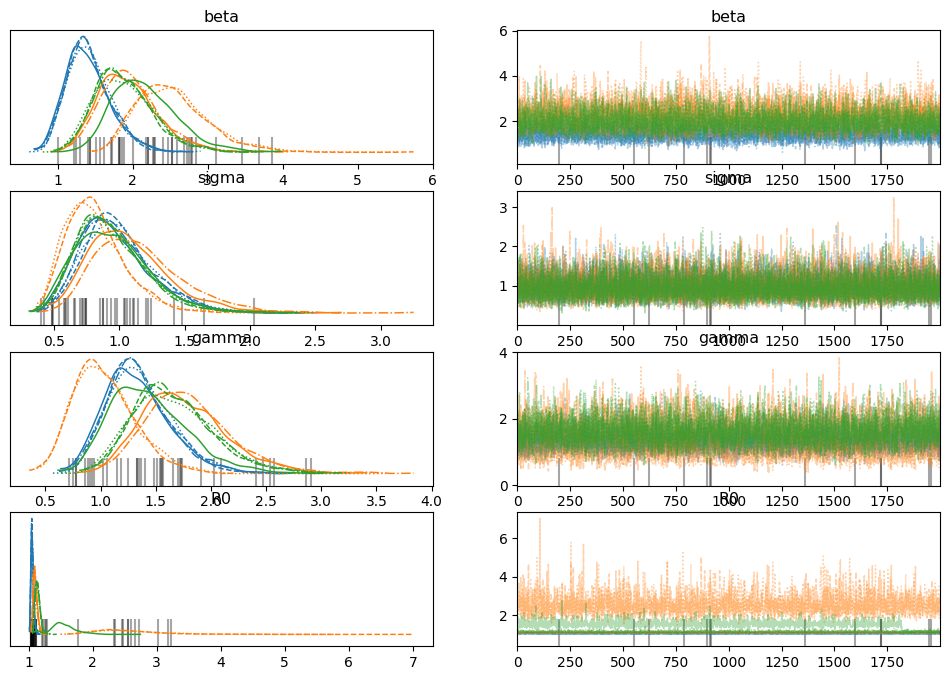

In [75]:
## trace plots
az.plot_trace(fit_patch_main, var_names=["beta", "sigma", "gamma", "R0"])
plt.show()

## POSTERIOR PREDICTIVE CHECK

In [76]:
import math

def plot_posterior_kde_grid(fit:any, parameters: list, n_cols: int, true_values: dict = None, save:str = None):
    """
    Plot KDEs of posterior samples for given parameters from a CmdStanMCMC fit.

    Args:
        fit (CmdStanMCMC): The fitted model.
        parameters (list of str): Names of parameters to plot.
        n_rows (int): Number of subplot rows.
        n_cols (int): Number of subplot columns.
        true_values (dict, optional): Dict mapping param names to true values for reference lines.
    """
    posterior_samples = fit.draws_pd()
    
    # Dynamically calculate the number of rows
    n_params = len(parameters)
    n_rows = math.ceil(n_params / n_cols)

    fig, ax = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows))
    ax = ax.flatten()  # flatten axes for easy indexing

    for i, param in enumerate(parameters):
        if param in posterior_samples.columns:
            sns.kdeplot(posterior_samples[param], fill=True, ax=ax[i])
            if true_values and param in true_values:
                ax[i].axvline(x=true_values[param], color='r', linestyle='--', label='True value')
                ax[i].legend()
            ax[i].set_xlabel(param)
            ax[i].set_ylabel('Density')
            ax[i].set_title(f'Posterior of {param}')
        else:
            ax[i].text(0.5, 0.5, f"{param} not found", ha='center', va='center')
            ax[i].axis('off')

    # Hide unused axes
    for j in range(len(parameters), len(ax)):
        ax[j].axis('off')

    
    if save:
        plt.savefig(f'./images/{save}.pdf', bbox_inches='tight')

    plt.tight_layout()
    plt.show()


In [77]:
# Get available variables
# Assuming `fit` is your CmdStanMCMC object from fitting the model
posterior_samples = fit_patch_main.draws_pd()  # returns a pandas DataFrame
parameters = ["beta[1]","beta[2]", "beta[3]", 
                "sigma[1]","sigma[2]","sigma[3]", 
                "gamma[1]","gamma[2]","gamma[3]",
                "incubation_period[1]","incubation_period[2]","incubation_period[3]", 
                "recovery_time[1]","recovery_time[2]","recovery_time[3]",
                "R0[1]","R0[2]", "R0[3]"]

beta = np.array([0.3, 0.4, 0.3])*7
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/9, 1/7, 1/6])*7   # 1/infectious period (Ebola: ~7 days)
phi = 10            # Negative binomial dispersion parameter
reporting_rate = 1
r = (beta/gamma)
rec = (1.0/gamma)
incu = (1.0 / sigma)

t = {
    'beta[1]': beta[0],
    'beta[2]': beta[1],
    'beta[3]': beta[2],
    'sigma[1]': sigma[0],
    'sigma[2]': sigma[1], 
    'sigma[3]': sigma[2],   
    'gamma[1]': gamma[0], 
    'gamma[2]': gamma[1], 
    'gamma[3]': gamma[2],
    'phi': phi ,
    'reporting_rate':1,
    'R0[1]': r[0], 'R0[2]': r[1], 'R0[3]': r[2], 
    'recovery_time[1]':rec[0],
    'recovery_time[2]':rec[1],
    'recovery_time[3]':rec[2],
    'incubation_period[1]': incu[0],
    'incubation_period[2]': incu[1],
    'incubation_period[3]': incu[2]}

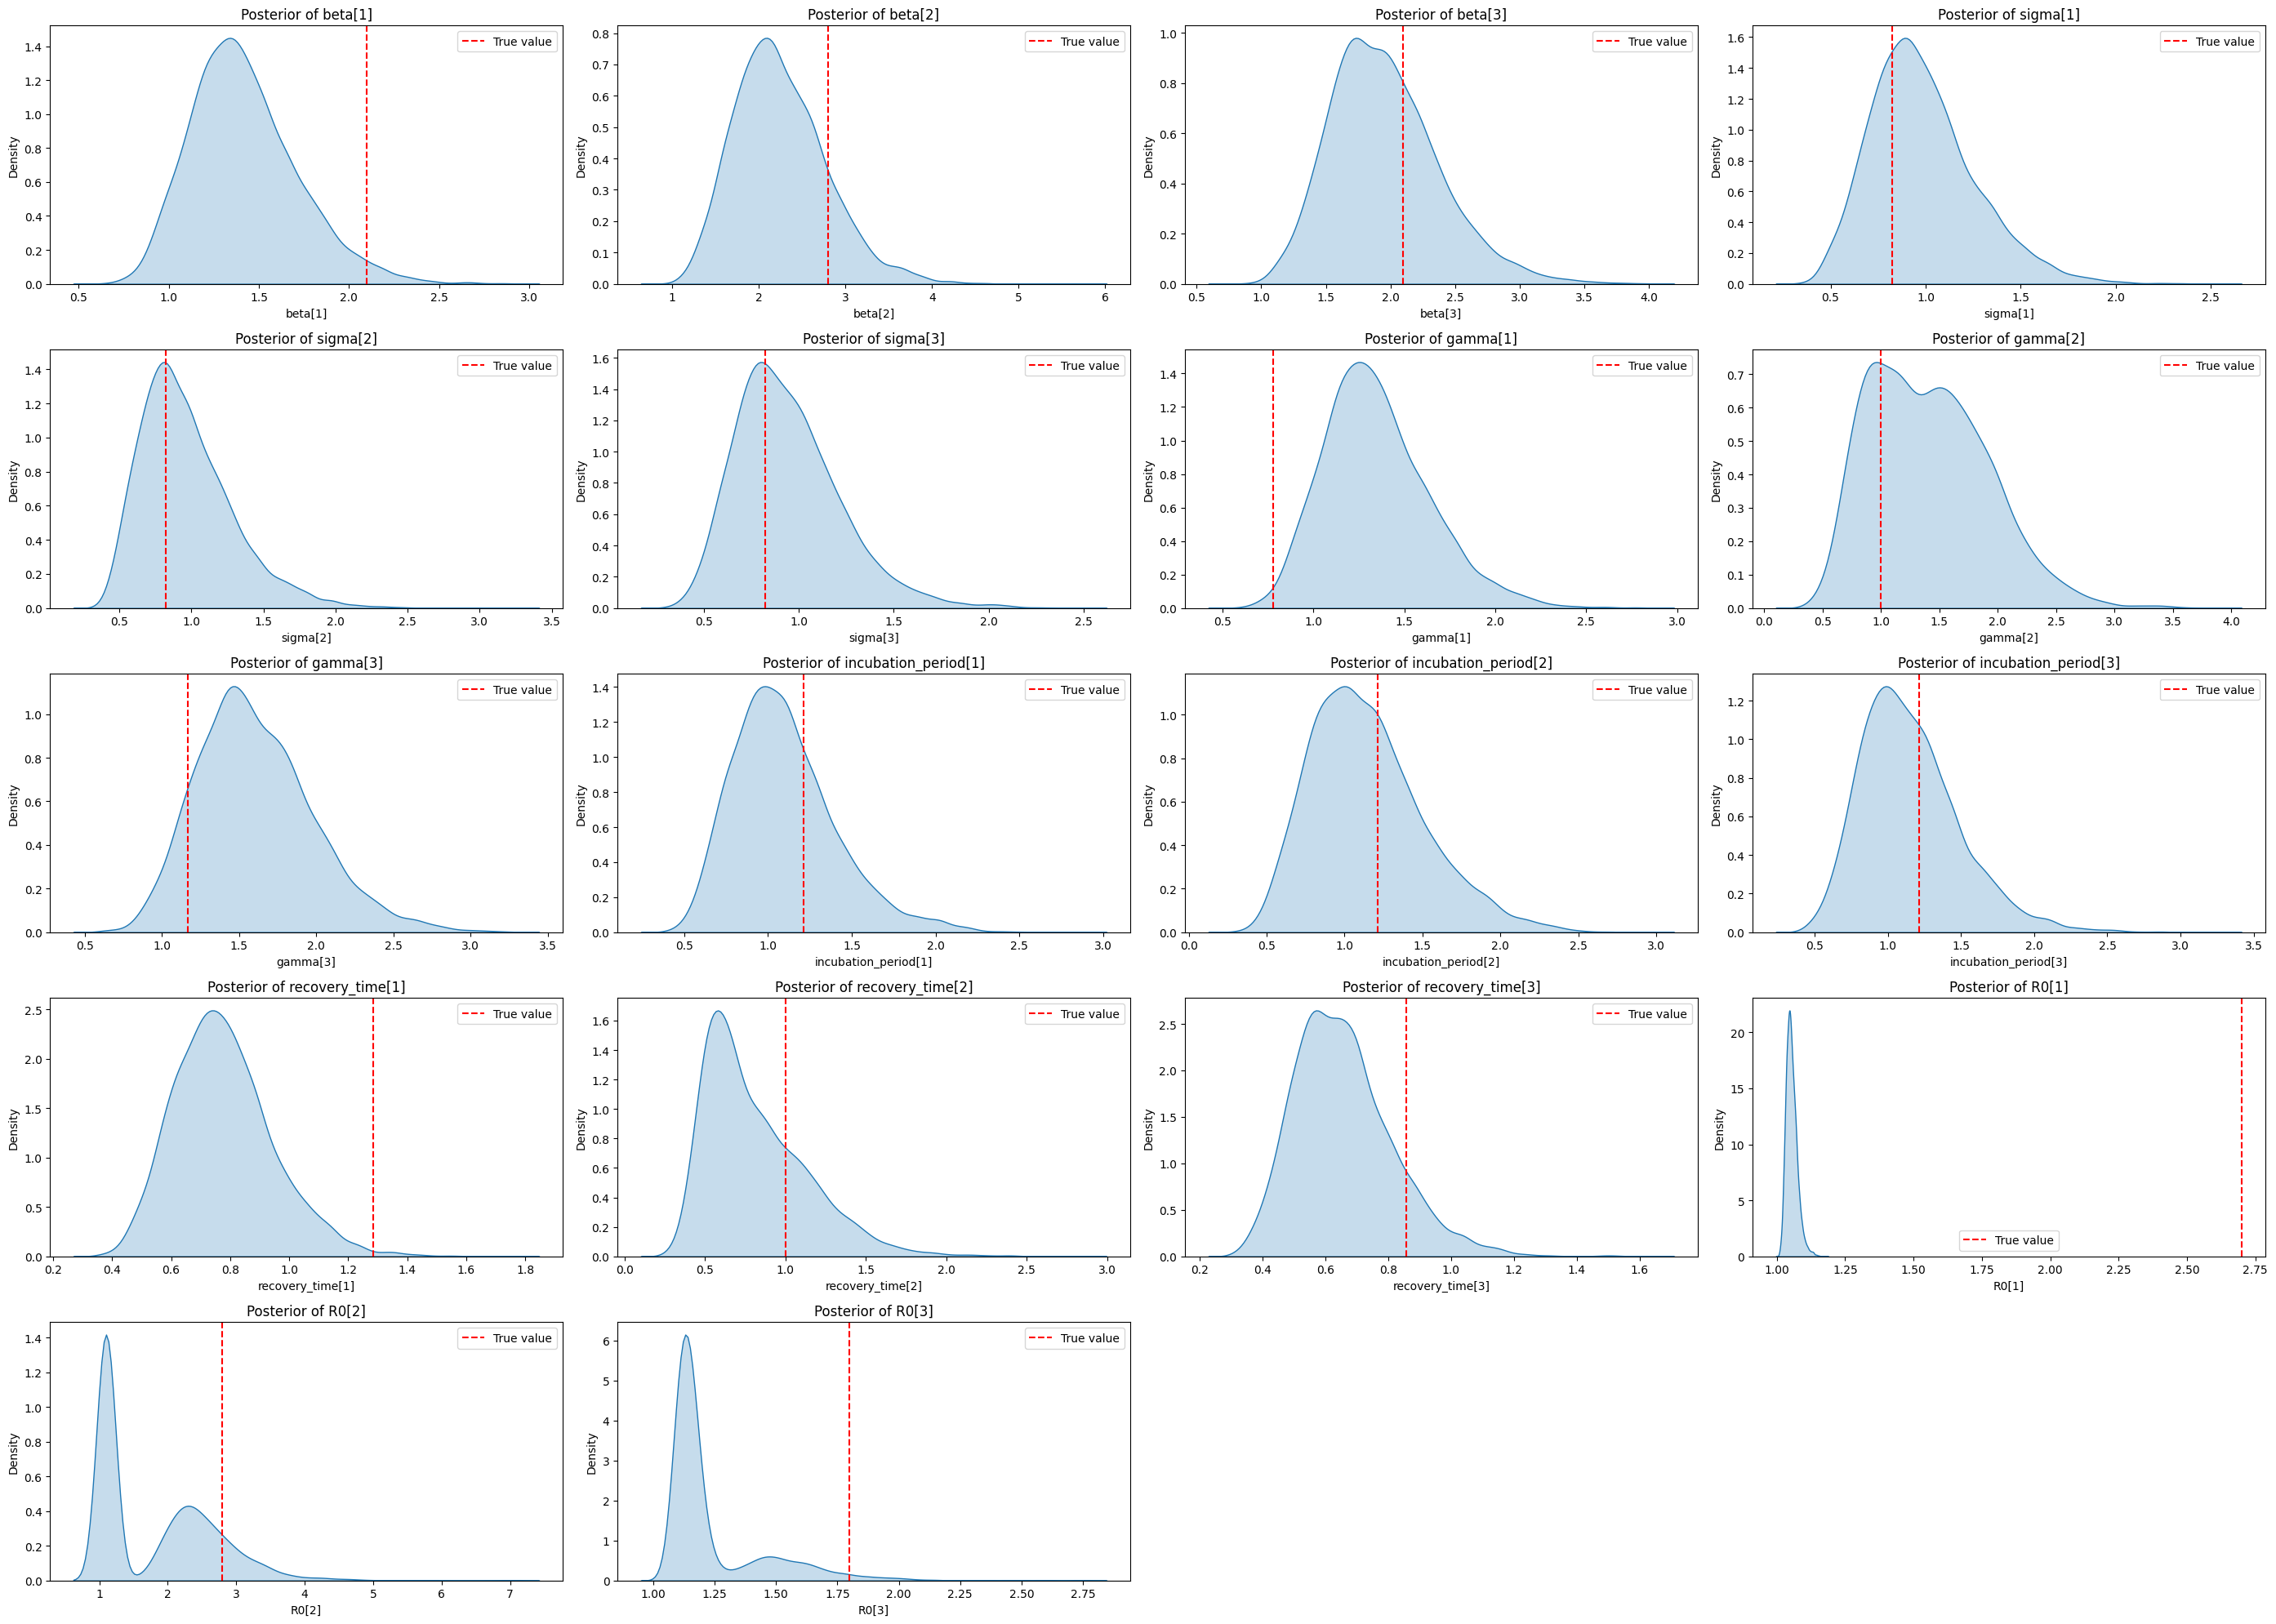

In [78]:
plot_posterior_kde_grid(fit_patch_main, parameters=parameters, 
                        n_cols=4, true_values=t)

## PRIOR PREDICTIVE CHECK

In [85]:

model_prior = CmdStanModel(stan_file = 'stan files/multi_patch_PRIOR.stan')
prior_check = model_prior.sample(data = seir_data,
                                     iter_sampling = 1000,
                                     chains = 4,
                                     seed = 20)

chain 1 |          | 00:00 Status



chain 1 |▍         | 00:02 Status






chain 1 |▉         | 00:42 Iteration:    1 / 2000 [  0%]  (Warmup)


chain 1 |█▎        | 01:00 Iteration:  100 / 2000 [  5%]  (Warmup)





chain 1 |█▊        | 01:23 Iteration:  200 / 2000 [ 10%]  (Warmup)

chain 1 |██▎       | 01:28 Iteration:  300 / 2000 [ 15%]  (Warmup)




chain 1 |██▋       | 01:32 Iteration:  400 / 2000 [ 20%]  (Warmup)


chain 1 |███▋      | 01:57 Iteration:  600 / 2000 [ 30%]  (Warmup)


chain 1 |████      | 02:04 Iteration:  700 / 2000 [ 35%]  (Warmup)





chain 1 |████▌     | 02:22 Iteration:  800 / 2000 [ 40%]  (Warmup)
chain 1 |█████     | 02:26 Iteration:  900 / 2000 [ 45%]  (Warmup)

chain 1 |█████▉    | 02:51 Iteration: 1001 / 2000 [ 50%]  (Sampling)






chain 1 |██████▎   | 03:31 Iteration: 1100 / 2000 [ 55%]  (Sampling)


chain 1 |██████▊   | 03:53 Iteration: 1200 / 2000 [ 60%]  (Sampling)


chain 1 |███████▎  | 04:17 Iteration: 1300 / 2000 [ 65%]  (Sampling)

chain 1 |██

In [86]:
import math
def plot_prior(model, param_names, boundary, ncols=3, 
               figsize_per_plot=(8, 7), 
               sharey=True, 
               legend_on_first=True):
    

    countries = ['Guinea','Liberia','Sierra Leone']
    n_params = len(param_names)
    nrows   = math.ceil(n_params / ncols)
    fig_w   = figsize_per_plot[0] * ncols
    fig_h   = figsize_per_plot[1] * nrows+1
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h))
    
    # flatten even if nrows or ncols == 1
    axes = np.array(axes).reshape(-1)
    
    for i, (ax, pname) in enumerate(zip(axes, param_names)):
        # pull samples: shape (n_samples, n_patches)
        samples = model.stan_variable(pname)
        df = pd.DataFrame(samples, columns=countries)
        
        # plot densities
        df.plot(kind='density', ax=ax, legend=False)
        ax.set_title(f'Prior predictive check for {pname}')
        ax.set_xlabel(pname)
        ax.grid(True)
        ax.axvline(x=boundary[i*2], color='r')
        ax.axvline(x=boundary[i*2+1], color='r')
    
    # hide any unused axes
    for ax in axes[n_params:]:
        ax.set_visible(False)

    
    # add legend if desired
    if legend_on_first and n_params > 0:
        axes[0].legend(countries, title='Patch')
    
    plt.tight_layout()
    return fig, axes


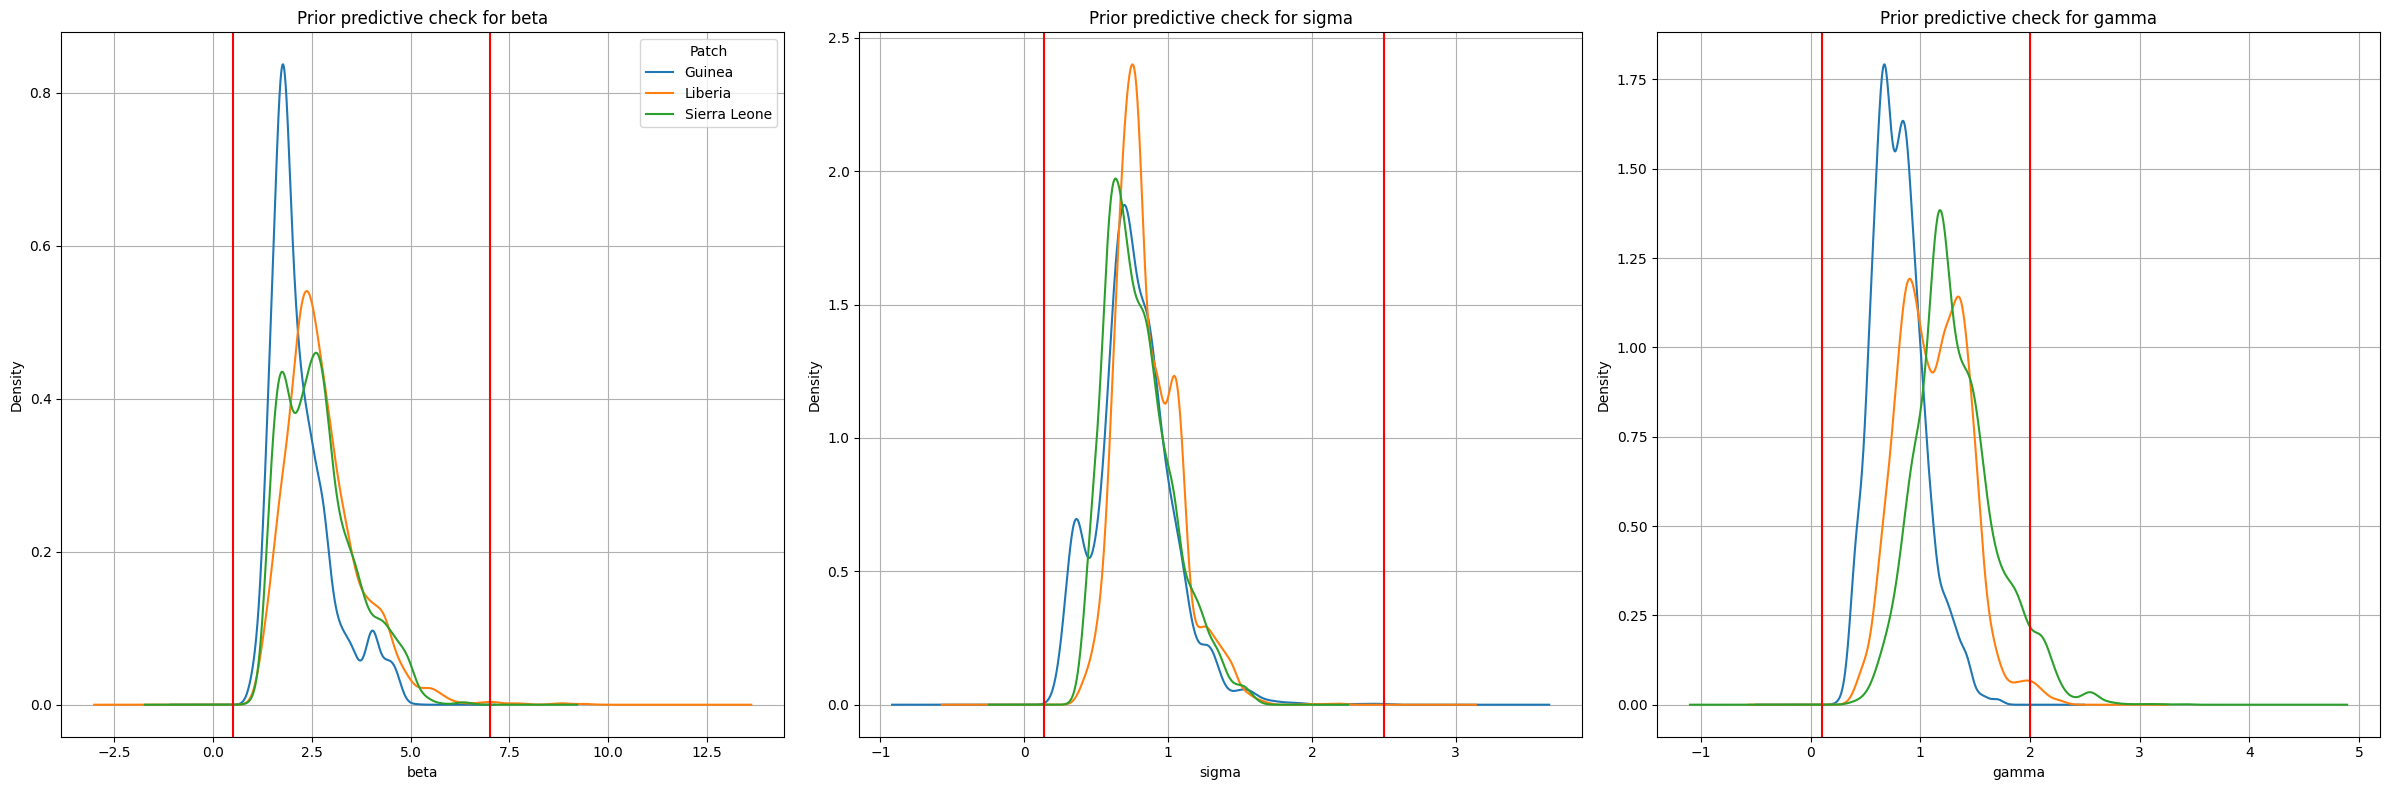

In [87]:
params = ['beta','sigma','gamma']
boundaries = [0.5, 7, 0.14, 2.5, 0.1, 2.0]

# 5 parameters → grid of 2×3 (since ncols=3)
fig, axes = plot_prior(prior_check, params, boundary = boundaries, ncols=3)
plt.show()


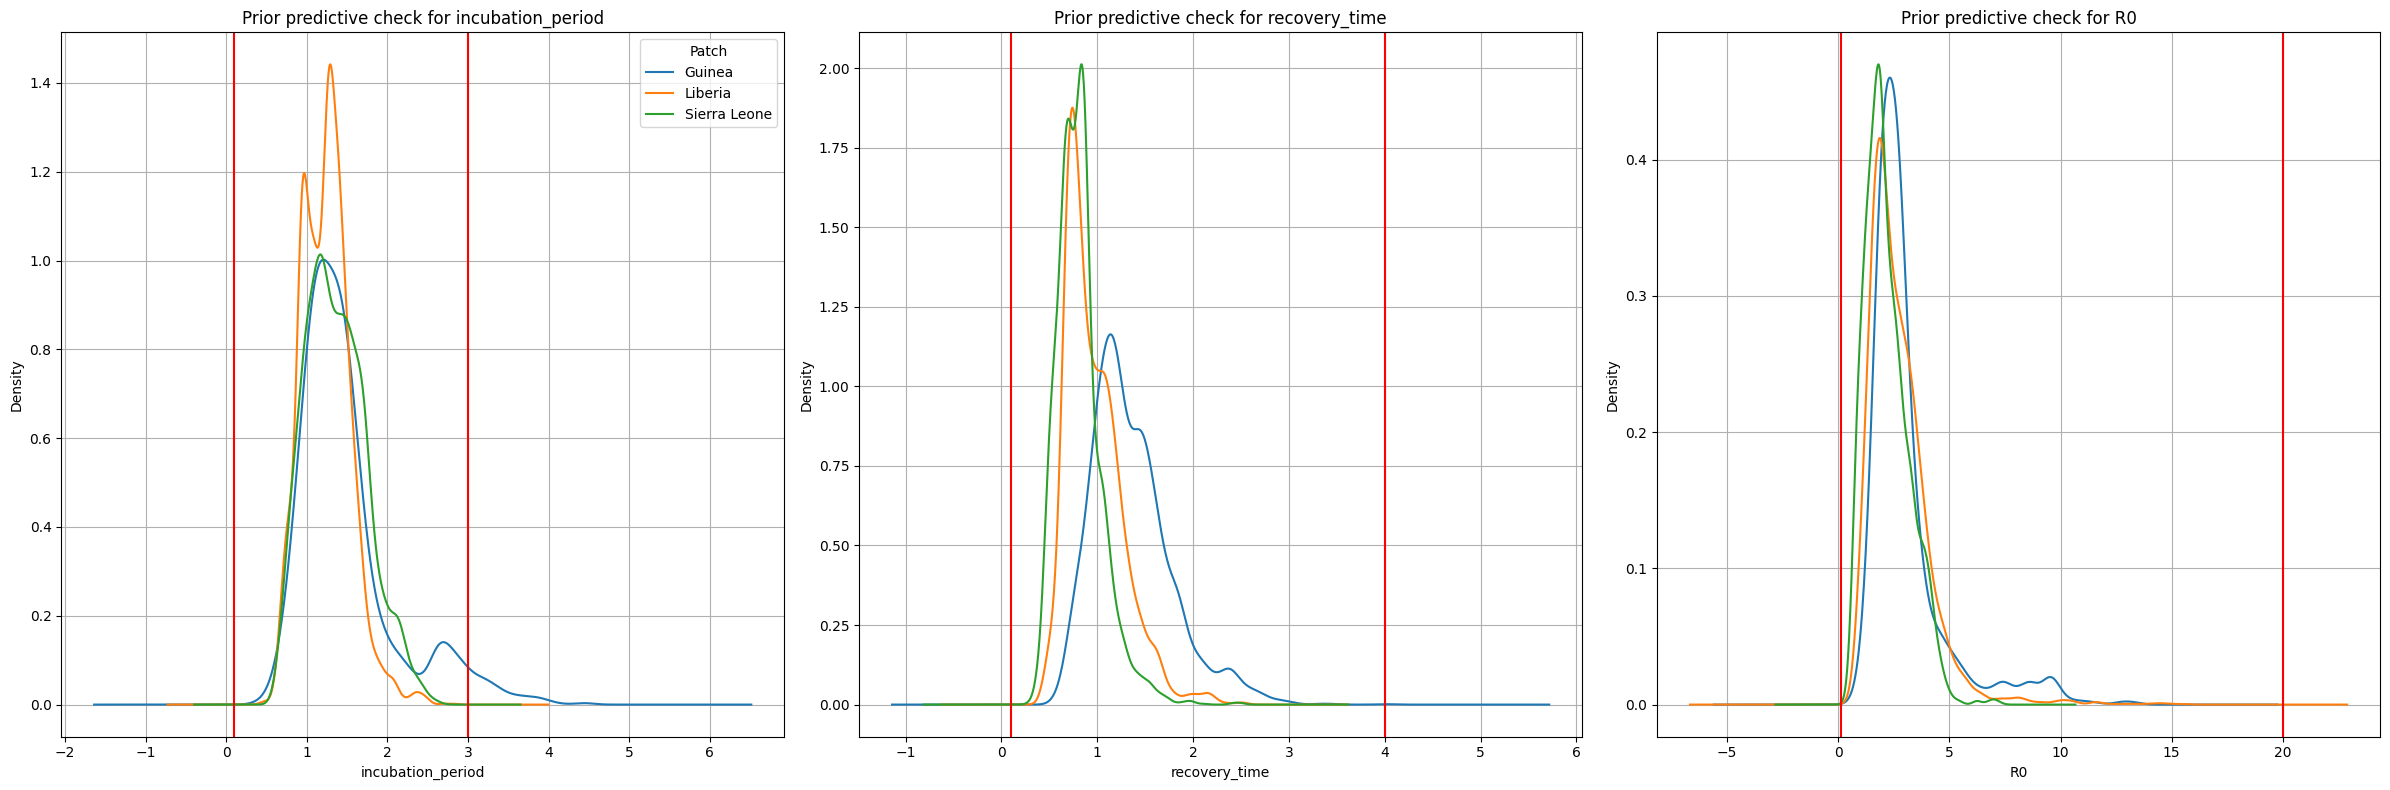

In [89]:
params = ['incubation_period','recovery_time','R0']
boundaries = [0.1, 3, 0.1, 4, 0.1, 20]

# 5 parameters → grid of 2×3 (since ncols=3)
fig, axes = plot_prior(prior_check, params, boundary = boundaries, ncols=3)
plt.show()


In [ ]:
# import matplotlib.pyplot as plt
# predicted_cases = fit_patch_model.stan_variable('pred_incidence')  # Shape: (samples, T, P)

# ## subplot (1,3)
# fig, axes = plt.subplots(1, 3, figsize=(30, 10))
# for p, country in enumerate(countries):
#     # for i in range(400):
#     #     plt.plot(data['ts'], predicted_cases[i, :, p], alpha=0.1, color='blue')
#     axes[p].plot(seir_data['t'], seir_data['cases'][p], 'o', label='Observed', color='green')
#     axes[p].plot(seir_data['t'], predicted_cases.mean(axis=0)[p, :], label='Mean Predicted', color='red')
#     axes[p].set_title(f'{country} Posterior Predictive')
#     axes[p].set_xlabel('Week')
#     axes[p].set_ylabel('Cases')
#     axes[p].legend()
# plt.show()

In [ ]:
# # Get available variables
# print("Available variables:", fit_patch_model.stan_variables().keys())

# # Time points and countries
# weeks = np.arange(fit_patch_model.stan_variable('incidence').shape[2])  # Number of weeks
# countries = ['Guinea', 'Liberia', 'Sierra Leone']

# # Plot incidence (infectious) and reconstructed other compartments
# for i, country in enumerate(countries):

#     # Create figure
#     fig, axes = plt.subplots(1, 1, figsize=(12, 5), sharex=True)
#         # Get median incidence
#     incidence = np.mean(fit_patch_model.stan_variable('incidence')[:, i,:], axis=0)

#     # Reconstruct approximate compartments (scaled by reporting rate)
#     rho = np.mean(fit_patch_model.stan_variable('reporting_rate')[i])
#     I = incidence / rho
#     R = np.cumsum(I) * np.mean(fit_patch_model.stan_variable('gamma')[i])
#     E = np.roll(I, 1) / np.mean(fit_patch_model.stan_variable('sigma')[i])  # Exposed ~ delayed infectious
#     E[0] = 0
#     S = seir_data['N'][i] - I - E - R

#     # Convert to fractions
#     S_frac = S# / seir_data['N'][i]
#     E_frac = E #/ seir_data['N'][i]
#     I_frac = I #/ seir_data['N'][i]
#     R_frac = R #/ seir_data['N'][i]

#     # Plot
#     plt.plot(weeks, S_frac, 'b', label='Susceptible')
#     plt.plot(weeks, E_frac, 'y', label='Exposed')
#     plt.plot(weeks, I_frac, 'r', label='Infectious')
#     plt.plot(weeks, R_frac, 'g', label='Recovered')

#     # Formatting
#     plt.title(f'{country} (R0={np.median(fit_patch_model.stan_variable("R0")[i, :]):.2f})')
#     plt.ylabel('Fraction of Population')
#     plt.grid(True, alpha=0.3)
#     # ax.set_ylim(0, 1)

#     plt.legend(loc='upper right')

#     plt.xlabel('Weeks since outbreak start')
#     plt.tight_layout()
#     plt.show()

# MODEL WITH COUPLING EFFECT

In [90]:
# Aggregate cases by country and week
countries = ['Guinea', 'Liberia', 'Sierra Leone']
# weekly_cases = ebola.groupby(['Country', pd.Grouper(key='OnsetDate', freq='W')]).size().unstack(fill_value=0).T
# weekly_cases = weekly_cases.reindex(columns=countries, fill_value=0)
cases = y #weekly_cases.values.T  # Shape: (T, 3)

N = np.array([11.5e6, 4.5e6, 6.8e6])
# N = np.array([20000, 1000, 30000])
# N = np.array([4e6, 2.5e6, 2e6])

beta = np.array([[0.3, 0.03, 0.02], 
           [0.03, 0.4, 0.05], 
           [0.02, 0.05, 0.35]])*7
# beta = np.array([0.3, 0.4, 0.35])*7
sigma = np.array([1/8.5, 1/8.5, 1/8.5])*7
gamma = np.array([1/9, 1/7, 1/6])*7

# Define initial conditions
g0 = np.array([N[0]-20, 10, 10, 0])
l0 = np.array([N[1]-11, 10, 1, 0])
s0 = np.array([N[2]-11, 10, 1, 0])

y0 = np.concatenate([g0, l0, s0]).flatten()

ts = cases

# Make the data struture
seir_data1 = {
    'N_patches': 3,
    "n_weeks": len(ts[0]),
    'y0': y0,
    't0': 0,
    "t": np.arange(1, len(ts[0])+1),
    "N": N.astype(int),
    "cases": ts,
    'beta_data': beta,
    'sigma_data': sigma,
    'gamma_data': gamma,
    'reporting_rate': reporting_rate
}

# print("Cases shape:", cases.shape)
# print("\nFirst few weeks:\n", cases)

main_meta_model = CmdStanModel(stan_file='stan files/metapopulation.stan')

In [ ]:
from datetime import datetime

fit_main_meta = main_meta_model.sample(data=seir_data1,
                        chains=4,
                        iter_sampling=2000,
                        parallel_chains=True,
                        iter_warmup=1000,
                        seed = 0)

# Generate timestamp for uniqueness
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save the fit output with a memorable name
output_dir = f'outputs/main_meta_{timestamp}'
Path(output_dir).mkdir(parents=True, exist_ok=True)

fit_main_meta.save_csvfiles(dir=output_dir)
print(f"\nFit for main metapopulation saved to: {output_dir}")

if __name__ == "__main__":
    print("Fits for main metapopulation completed. Check 'output/' directory.")

chain 1 |          | 00:00 Status


chain 1 |██████████| 2:52:39 Iteration: 2900 / 3000 [ 96%]  (Sampling)

---
### 1. Residents of patch i currently in patch j

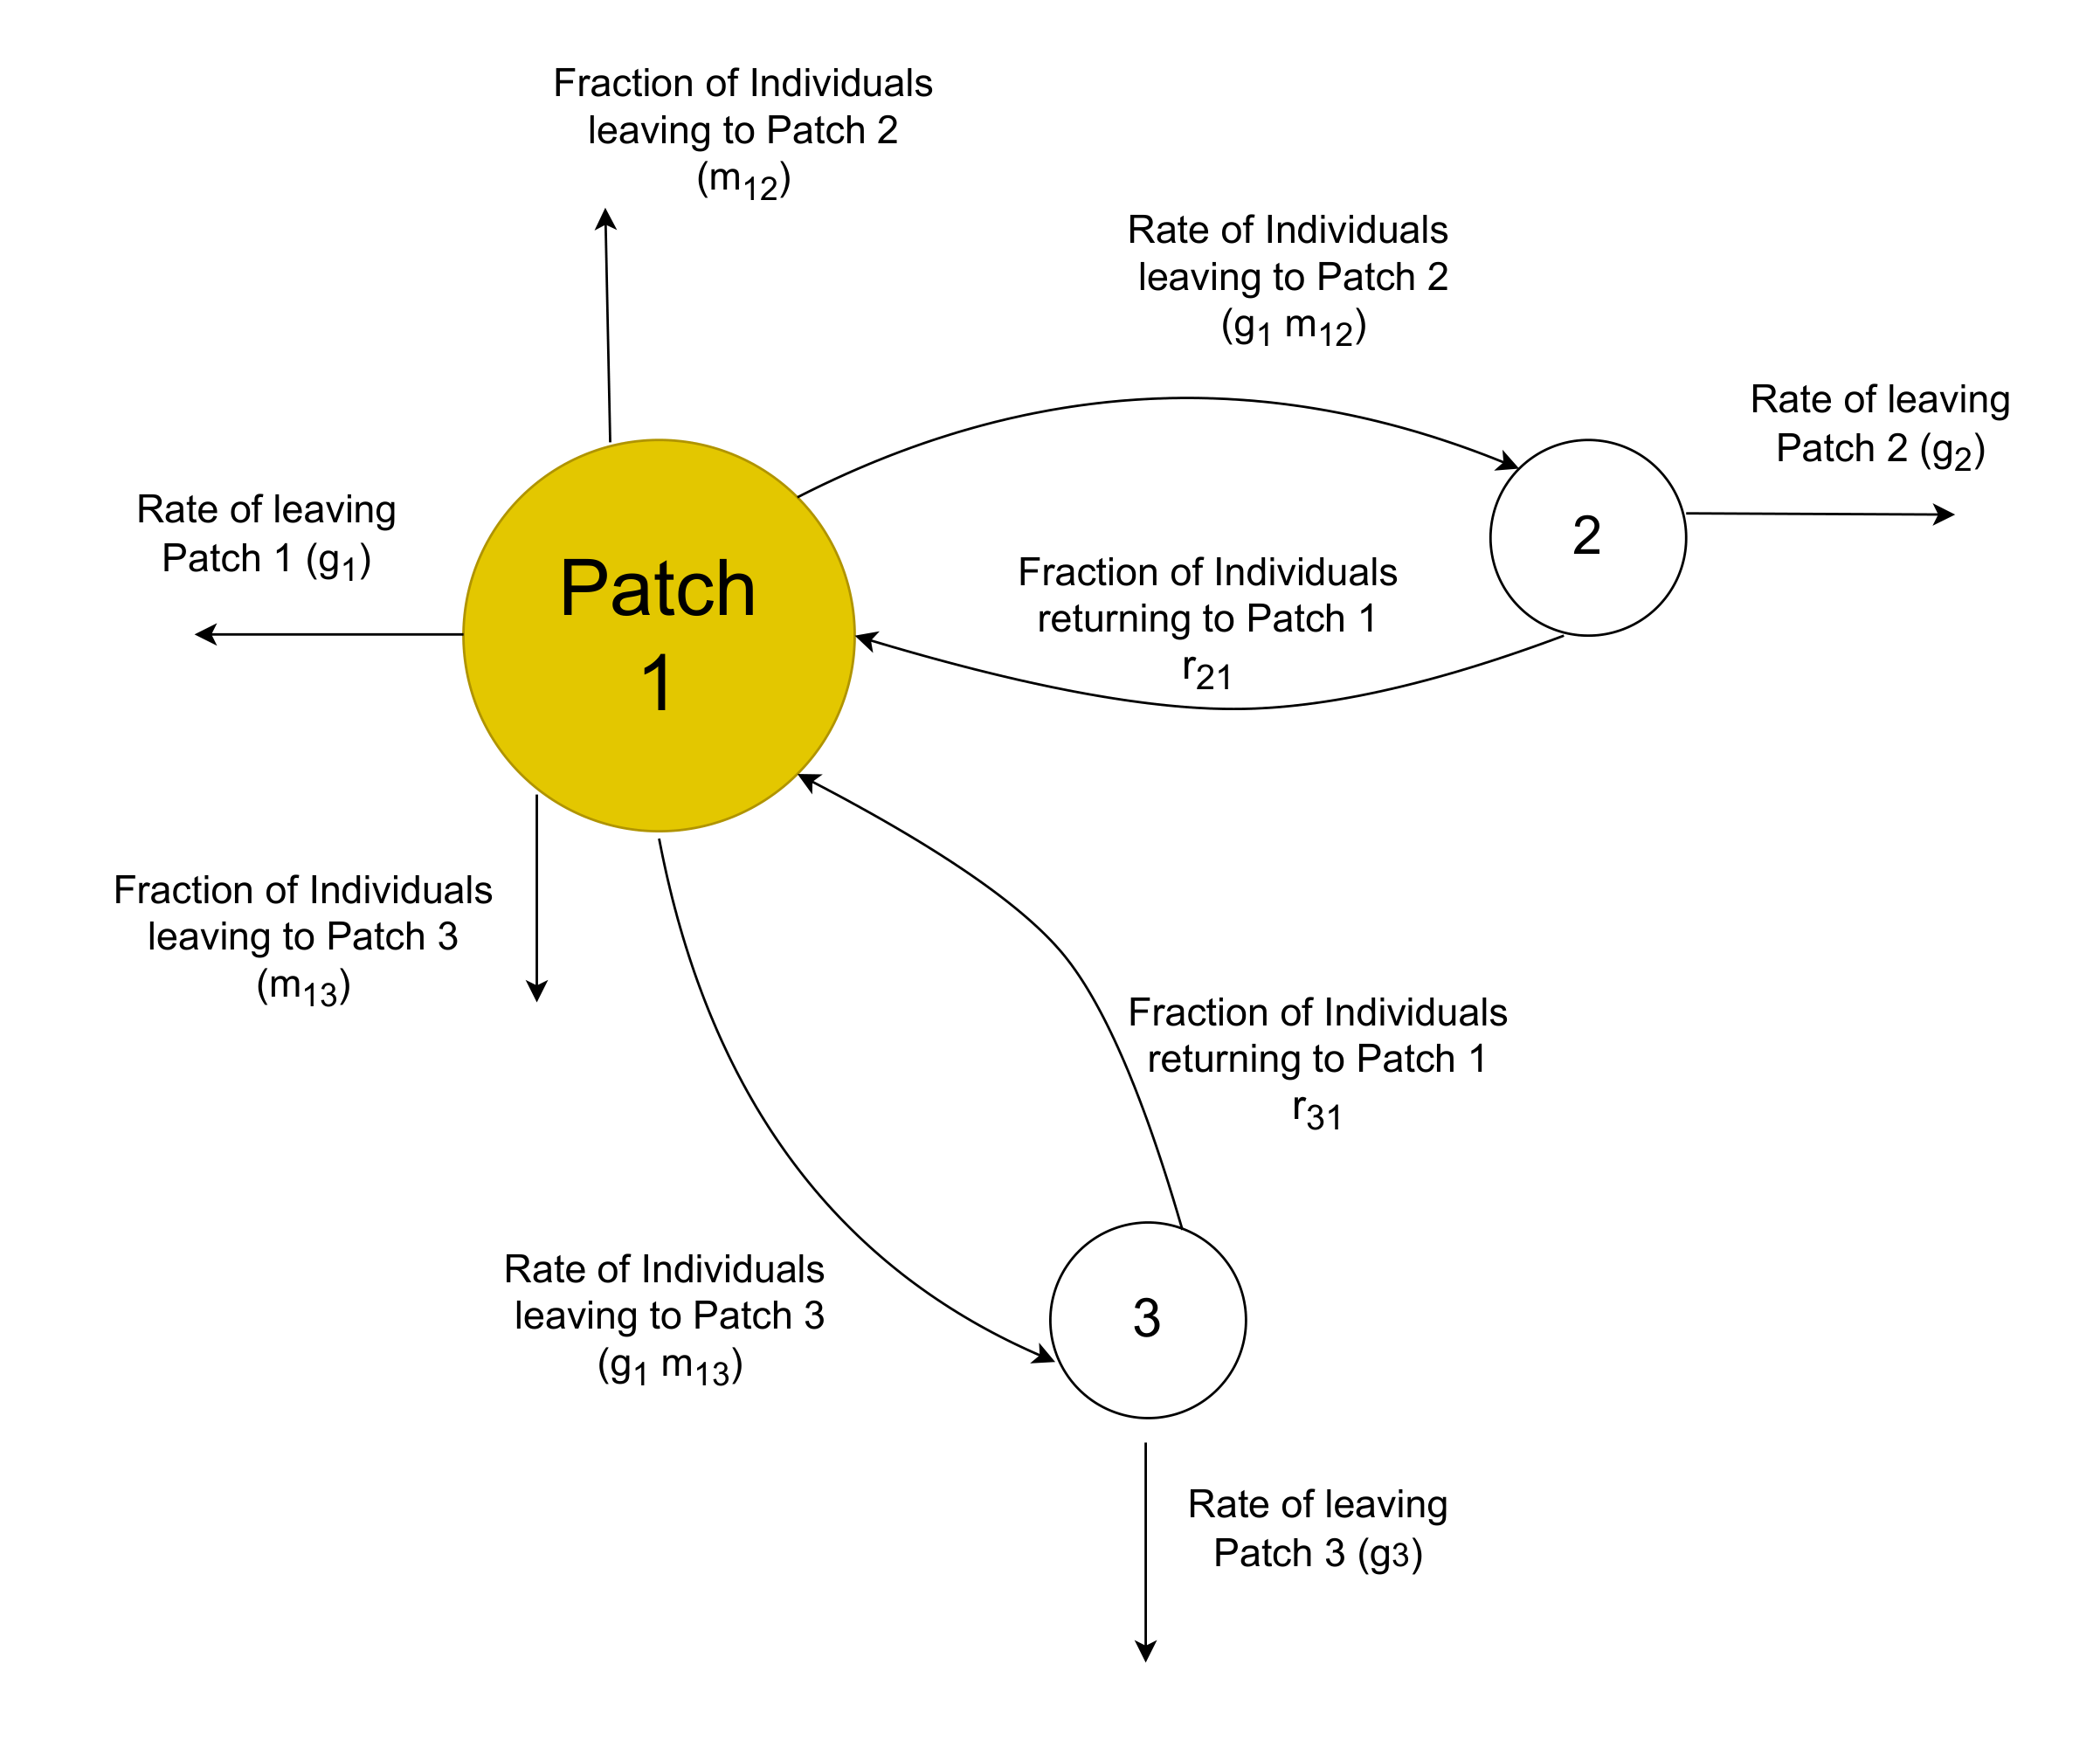
---
$$
\begin{aligned}
S'_{ij} &= -\sum_{k=1}^n k_j \beta_{ikj}\frac{S_{ij}I_{kj}}{N_j} + g_i m_{ji}S_{ii} - r_{ij}S_{ij}\\
E'_{ij} &= \sum_{k=1}^n k_j \beta_{ikj}\frac{S_{ij}I_{kj}}{N_j} - \sigma E_{ij} + g_i m_{ji}E_{ii} - r_{ij}E_{ij}\\
I'_{ij} &= \sigma E_{ij} - \gamma I_{ij} + g_im_{ji}I_{ii} - r_{ij}I_{ij}\\
R'_{ij} &= \gamma I_{ij} + g_im_{ji}R_{ii} - r_{ij}R_{ij}
\end{aligned}
$$

---

In [ ]:
# # Aggregate cases by country and week
# countries = ['Guinea', 'Liberia', 'Sierra Leone']
# # weekly_cases = ebola.groupby(['Country', pd.Grouper(key='OnsetDate', freq='W')]).size().unstack(fill_value=0).T
# # weekly_cases = weekly_cases.reindex(columns=countries, fill_value=0)
# cases = y #weekly_cases.values.T  # Shape: (T, 3)

# # N = np.array([11.5e6, 4.5e6, 6.8e6])
# N = np.array([15000, 20000, 30000])
# # N = np.array([4e6, 2.5e6, 2e6])
# # Set the population size
# beta = np.array([0.3, 0.4, 0.35])*7
# sigma = np.array([1/10, 1/7, 1/6])*7
# gamma = np.array([1/7, 1/4, 1/5])*7

# kappa = np.array([2.0, 1.5, 1.8])  # Contact rates

# ## Travel and return rate
# g = np.array([0.001, 0.001, 0.001])  # Travel rates
# m = np.array([[0, 0.00054, 0.00063], [0.000064, 0, 0.000036], [0.0001, 0.0001, 0]])  # Travel fractions
# r = np.array([[0, 0.5, 0.5], [0.5, 0, 0.5], [0.5, 0.5, 0]])  # Return rates
# gm = g*m

# # Define initial conditions
# g0 = [[N[0] - 10, 10, 10, 0,0], [N[0] - 10, 10, 10, 0,0], [N[0] - 10, 10, 10, 0,0]]
# l0 = [[N[1] - 1, 10, 1, 0,0], [N[1] - 1, 10, 1, 0,0], [N[1] - 1, 10, 1, 0,0]]
# s0 = [[N[2] - 1, 10, 1, 0,0], [N[2] - 1, 10, 1, 0,0], [N[2] - 1, 10, 1, 0,0]]

# ts = cases
# # y0 = [g0, l0, s0]

# y0 = np.zeros((3, 3, 5))  # 3 patches, 5 compartments (S,E,I,R,C)
# for i in range(3):
#     y0[i,i,0] = N[i] - 1  # S_ii
#     y0[i,i,2] = 1          # I_ii seed
#     # C starts at 0

# seir_data1 = {
#     'n_patches': 3,
#     "n_weeks": len(ts[0]),
#     'y0': y0,
#     't0': 0,
#     "ts": np.arange(1, len(ts[0])+1),
#     "N": N.astype(int),
#     "cases": ts,
#     'r_values':r ,
#     'g_values': g,
#     'm_values': m,
#     'kappa_values': kappa,
#     'reporting_rate': 1,
#     'beta_values': beta,
#     'sigma_values': sigma,
#     'gamma_values': gamma
# }

# # print("Cases shape:", cases.shape)
# # print("\nFirst few weeks:\n", cases)

# couplingmodel = CmdStanModel(stan_file='stan files/coupling_between_patches.stan')

In [ ]:
# fit_coupling_model = couplingmodel.sample(data=seir_data1,
#                         chains=4,
#                         iter_sampling=5,
#                         parallel_chains=True,
#                         iter_warmup=5,
#                         seed=20)

---
### 2. Residents of patch i currently in patch i

---

$$
\begin{aligned}
{S'}_{ii} &= -\sum_{k=1}^n \beta_{ik} \frac{S_{ii} I_{kj}}{N_j} + \sum_{k=1}^n r_{ij} S_{ii} - g_i S_{ii} \\
{E'}_{ii} &= \sum_{k=1}^n \beta_{ik} \frac{S_{ii} I_{kj}}{N_j} - \sigma E_{ii} + \sum_{k=1}^n r_{ij} E_{ii} - g_i E_{ii} \\
{I'}_{ii} &= \sigma E_{ii} - \gamma I_{ii} + \sum_{k=1}^n r_{ij} I_{ii} - g_i I_{ii} \\
{R'}_{ii} &= \gamma I_{ii} + \sum_{k=1}^n r_{ij} R_{ii} - g_i R_{ii}
\end{aligned}
$$

---